In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, r2_score

from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.compose import ColumnTransformer

Mathematical Transformers: Converts data into Normal Distributions which is helpful for algorithms like Linear Regeression, Logistic Regression, etc.

We can find out whether a PDF is normal or not by


*   sns.displot()
*   pd.skew() value
*   QQ plot



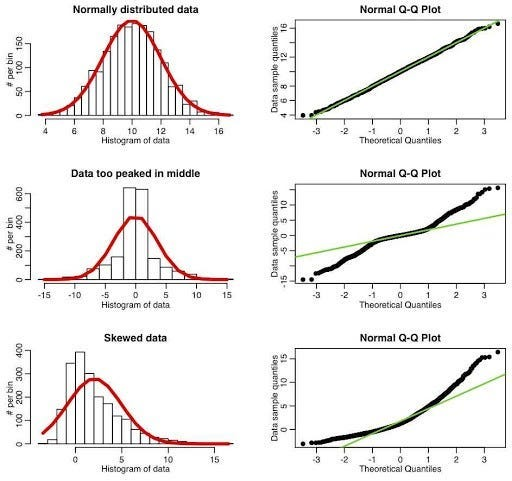

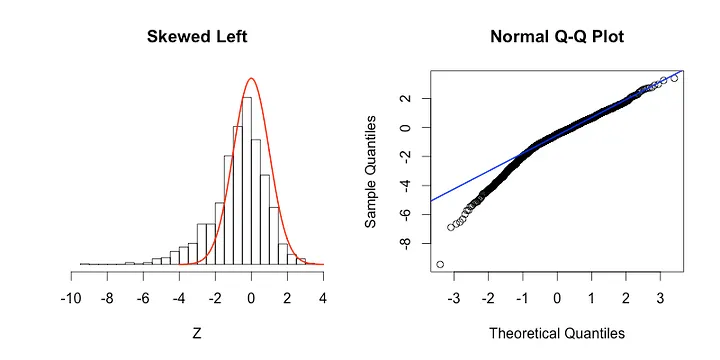

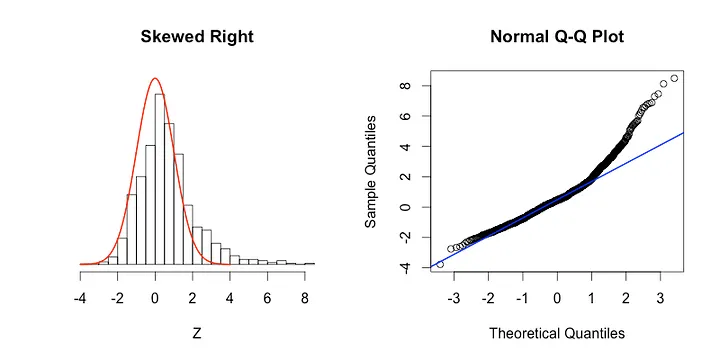

1) Normal Data: QQ Plot on the line
2) Skewed Left Data: QQ plot off the line from below
3) Skewed Right Data: QQ plot off the line from above
4) Too peaked in the middle: QQ plot off the line from both above and below

# 1) Function Transformer

Types:
1) Log Transform
2) Reciprocal Transform
3) Sqrt Transform
4) Custom Transform

In [3]:
data = pd.read_csv("train.csv")

In [4]:
data.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
550,551,1,1,"Thayer, Mr. John Borland Jr",male,17.0,0,2,17421,110.8833,C70,C
568,569,0,3,"Doharr, Mr. Tannous",male,NaN,0,0,2686,7.2292,NaN,C
825,826,0,3,"Flynn, Mr. John",male,NaN,0,0,368323,6.9500,NaN,Q
753,754,0,3,"Jonkoff, Mr. Lalio",male,23.0,0,0,349204,7.8958,NaN,S
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61.0,0,0,111240,33.5000,B19,S


In [6]:
data = data[["Age","Fare","Survived"]]

In [7]:
data.sample(5)

,Age,Fare,Survived
767,30.5,7.750,0
147,9.0,34.375,0
573,NaN,7.750,1
323,22.0,29.000,1
595,36.0,24.150,0


In [11]:
# Make sure there are no missing values before using Function Transformer

In [8]:
data.isna().sum()

,0
Age,177
Fare,0
Survived,0


In [9]:
data["Age"].fillna(data["Age"].mean(), inplace=True)

/tmp/ipython-input-493785903.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].mean(), inplace=True)


In [10]:
data.isna().sum()

,0
Age,0
Fare,0
Survived,0


In [12]:
X = data.drop(["Survived"],axis=1)
y = data["Survived"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=32)

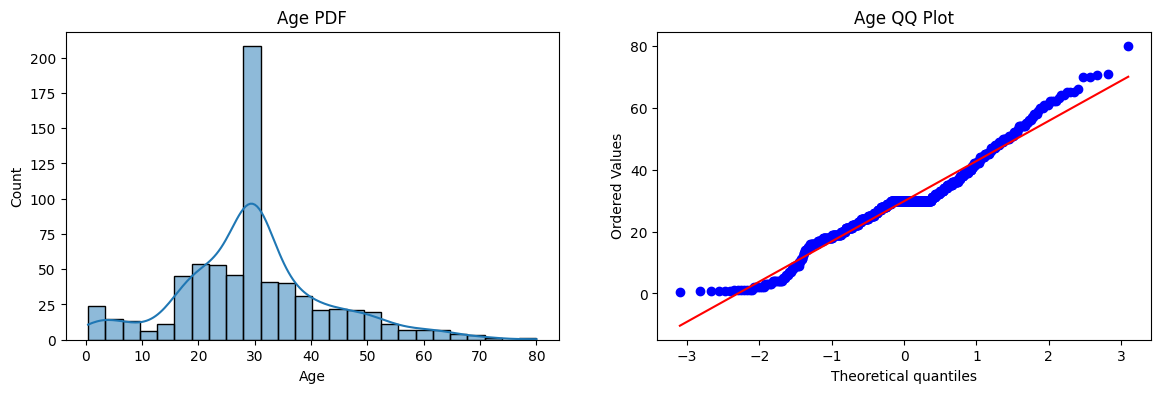

In [20]:
# Current distribution : Age

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(x=X_train["Age"],kde=True)
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(X_train["Age"],dist="norm", plot = plt)
plt.title("Age QQ Plot")

plt.show()

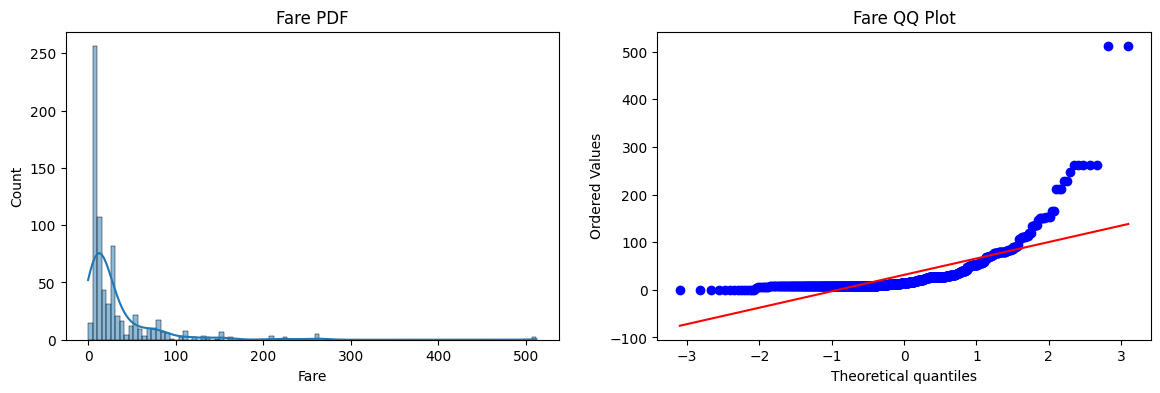

In [21]:
# Current distribution : Fare

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(x=X_train["Fare"],kde=True)
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(X_train["Fare"],dist="norm", plot = plt)
plt.title("Fare QQ Plot")

plt.show()

In [25]:
# Non transformed accuracies
lr = LogisticRegression()
dtree = DecisionTreeClassifier()

lr.fit(X_train, y_train)
dtree.fit(X_train, y_train)

y_test1 = lr.predict(X_test)
y_test2 = dtree.predict(X_test)

accuracy_lr = np.mean(cross_val_score(lr, X_train, y_train, cv=5))
accuracy_dtree = np.mean(cross_val_score(dtree, X_train, y_train, cv=5))

print(f"Accuracy Logistic Regressor: {accuracy_lr*100}%")
print(f"Accuracy Decision Tree Classifier: {accuracy_dtree*100}%")

Accuracy Logistic Regressor: 66.00709150004924%
Accuracy Decision Tree Classifier: 64.76016940805674%


a) Log Transform :- Takes the log of each value in that column where log transform is used. Reduces large scaled and distant values near to each other

Used when:

*   Only have positive values data
*   Data is right skewed



In [26]:
# Only apply log transform on "Fare" column as "Age" is already nearly normal

In [30]:
transformer = ColumnTransformer(transformers=[
    ("log", FunctionTransformer(func=np.log1p), ["Fare"])
], remainder="passthrough")

X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

In [31]:
lr = LogisticRegression()
dtree = DecisionTreeClassifier()

lr.fit(X_train, y_train)
dtree.fit(X_train, y_train)

y_test1 = lr.predict(X_test)
y_test2 = dtree.predict(X_test)

accuracy_lr_transformed = np.mean(cross_val_score(lr, X_train, y_train, cv=5, scoring="accuracy"))
accuracy_dtree_transformed = np.mean(cross_val_score(dtree, X_train, y_train, cv=5, scoring="accuracy"))

print(f"LR Post Transformation: {accuracy_lr_transformed * 100}%")
print(f"DTree Post Transformation: {accuracy_dtree_transformed * 100}%")

LR Post Transformation: 66.00709150004924%
DTree Post Transformation: 64.62227912932138%


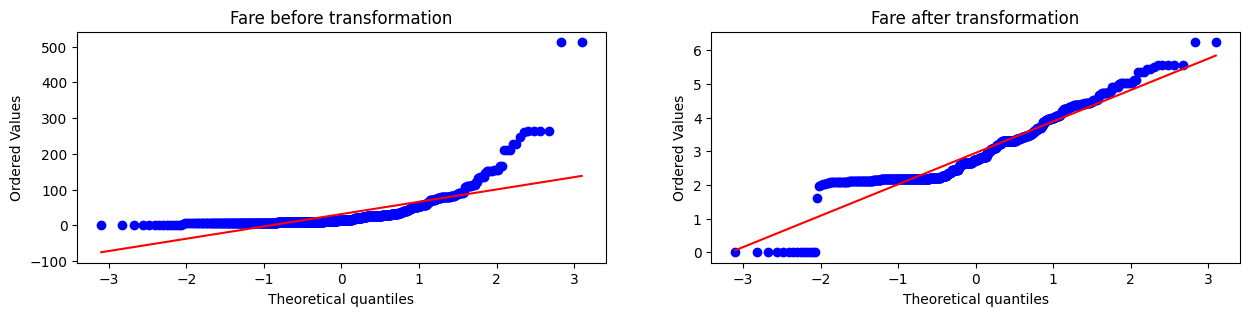

In [36]:
plt.figure(figsize=(15,3))

plt.subplot(121)
stats.probplot(X_train["Fare"], dist="norm", plot=plt)
plt.title("Fare before transformation")

plt.subplot(122)
stats.probplot(X_train_transformed[:, 0], dist="norm", plot=plt)
plt.title("Fare after transformation")

plt.show()


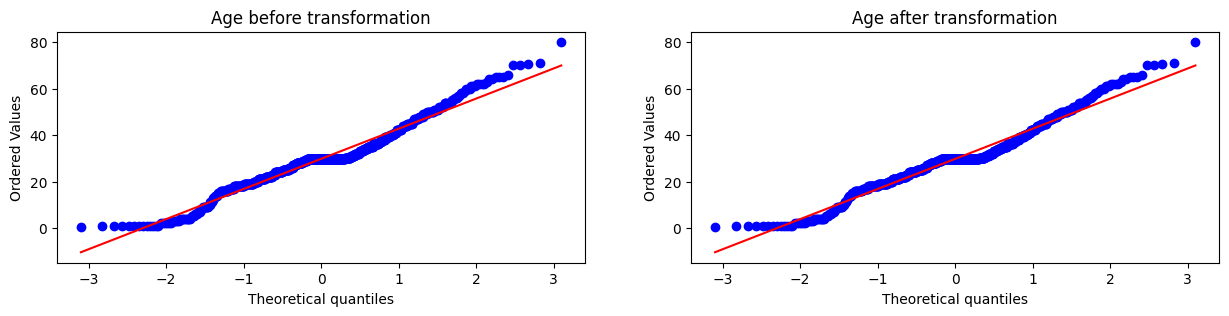

In [37]:
plt.figure(figsize=(15,3))

plt.subplot(121)
stats.probplot(X_train["Age"], dist="norm", plot=plt)
plt.title("Age before transformation")

plt.subplot(122)
stats.probplot(X_train_transformed[:, 1], dist="norm", plot=plt)
plt.title("Age after transformation")

plt.show()


In [38]:
# General Function for all transformation

In [55]:
def apply_transformation(transform_func):
  X = data.iloc[:,0:2]
  y = data.iloc[:,2]

  transformer = ColumnTransformer(transformers=[
      ("log", FunctionTransformer(func=transform_func), ["Fare"])
  ], remainder="passthrough")

  X_transformed = transformer.fit_transform(X)

  model = LogisticRegression()

  accuracy = np.mean(cross_val_score(model, X_transformed, y, cv=10, scoring="accuracy"))

  print(f"Accuracy: {accuracy}")

  plt.figure(figsize=(15,3))

  plt.subplot(121)
  stats.probplot(X["Fare"], dist="norm", plot=plt)
  plt.title("Fare before transformation")

  plt.subplot(122)
  stats.probplot(X_transformed[:, 0], dist="norm", plot=plt)
  plt.title("Fare after transformation")

  plt.show()

Accuracy: 0.6712609238451936


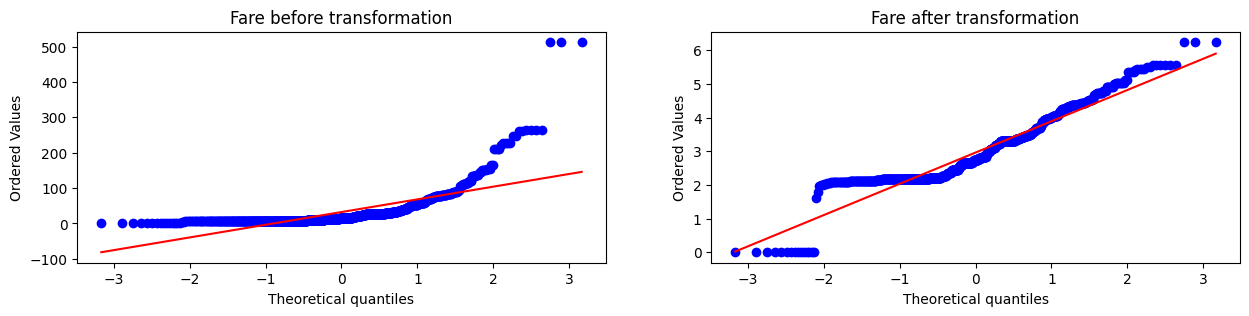

In [59]:
# Log
apply_transformation(lambda x: np.log(x+1))

Accuracy: 0.6431335830212235


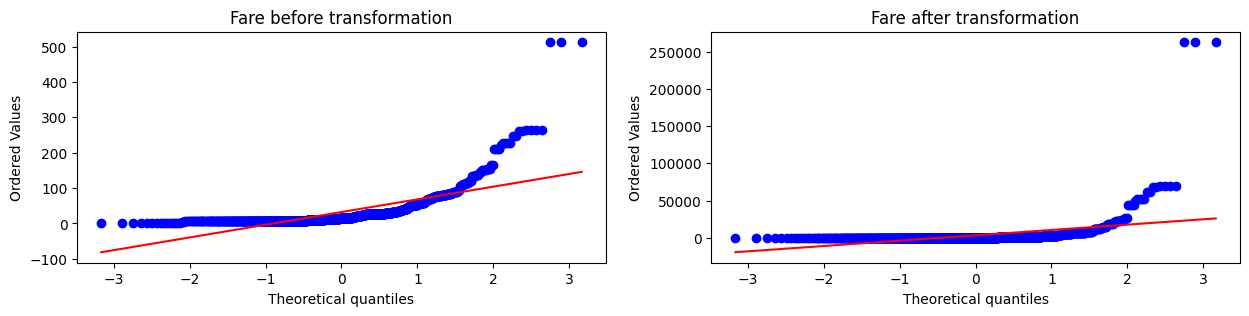

In [60]:
# Square
apply_transformation(lambda x: x**2)

Accuracy: 0.6589013732833957


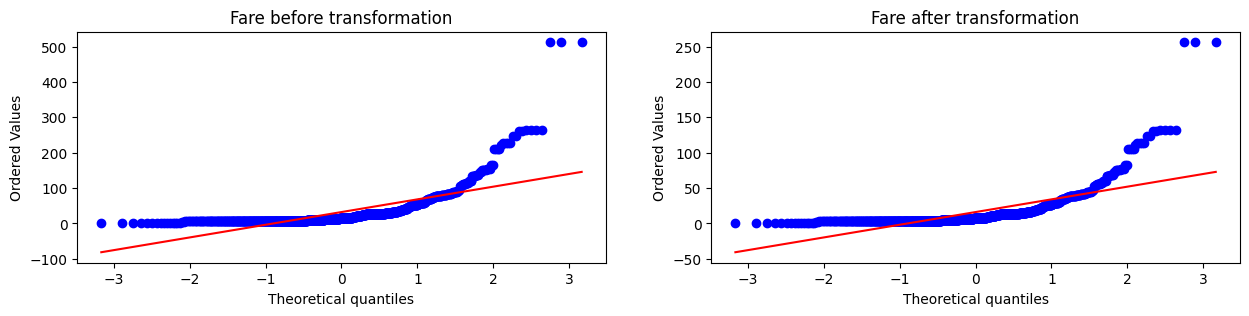

In [61]:
# Square Root
apply_transformation(lambda x: x**1/2)

Accuracy: 0.61729088639201


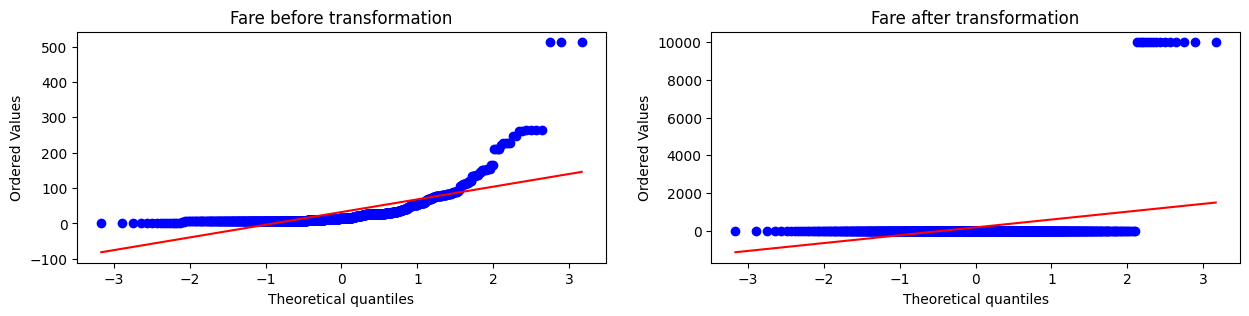

In [63]:
# Reciprocal
apply_transformation(lambda x: 1/(x+0.0001))

# 2) Power Transformer

Types:
1) Box Cox
2) Yeo-Johnson

Box Cox cannot work on negative values and zeroes but Yeo Johnson can

In [64]:
data = pd.read_csv("concrete_data.csv")

In [65]:
data.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
281,251.4,0.0,118.3,188.5,6.4,1028.4,757.7,28,32.66
279,251.4,0.0,118.3,188.5,6.4,1028.4,757.7,3,13.12
55,198.6,132.4,0.0,192.0,0.0,978.4,825.5,7,14.64
788,349.0,0.0,0.0,192.0,0.0,1047.0,806.0,7,18.13
780,238.0,0.0,0.0,185.0,0.0,1118.0,789.0,28,17.54


In [67]:
data.isna().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [68]:
data.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [69]:
X = data.drop("Strength",axis=1)
y = data["Strength"]

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=32)

In [71]:
# Non transformed modelling
lr = LinearRegression()

lr.fit(X_train, y_train)

r2 = r2_score(y_test, lr.predict(X_test))

r2

0.5848844773455903

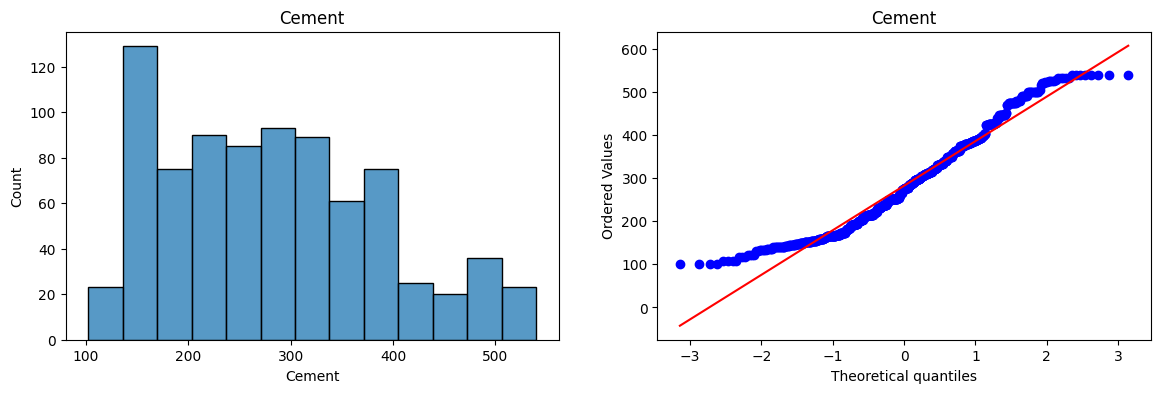

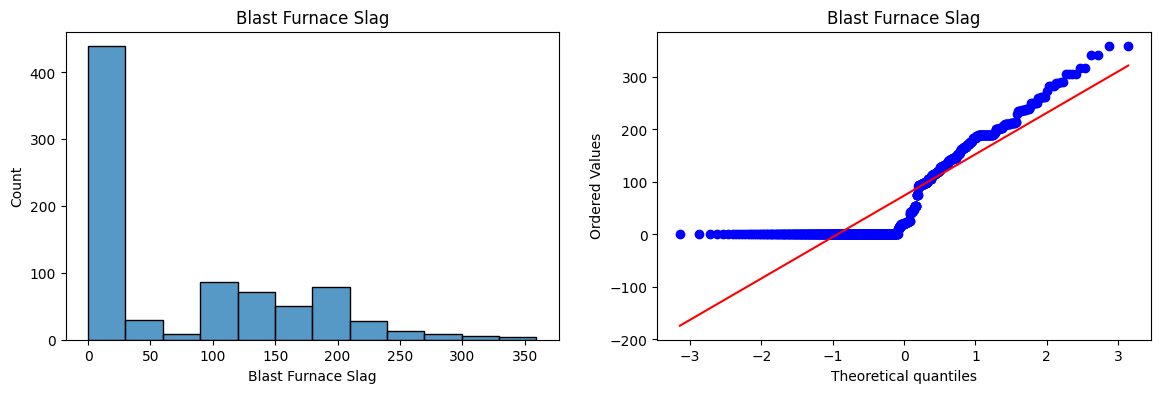

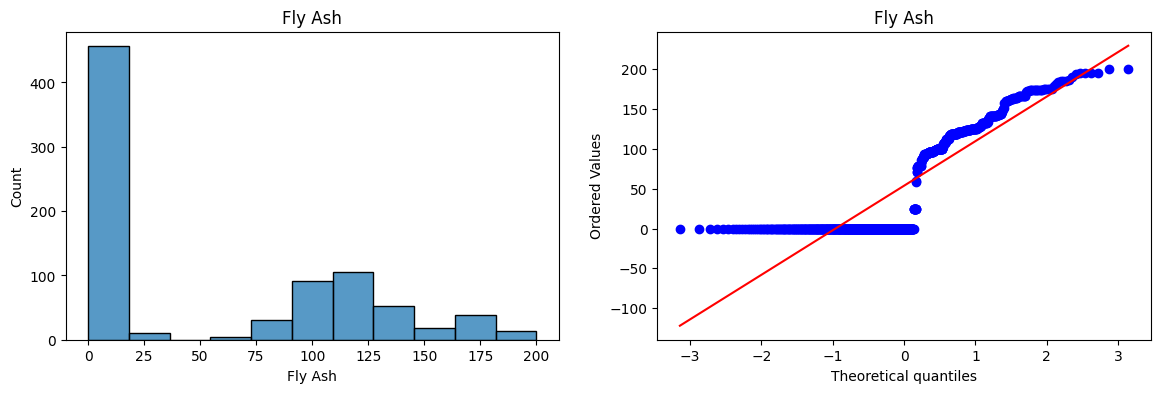

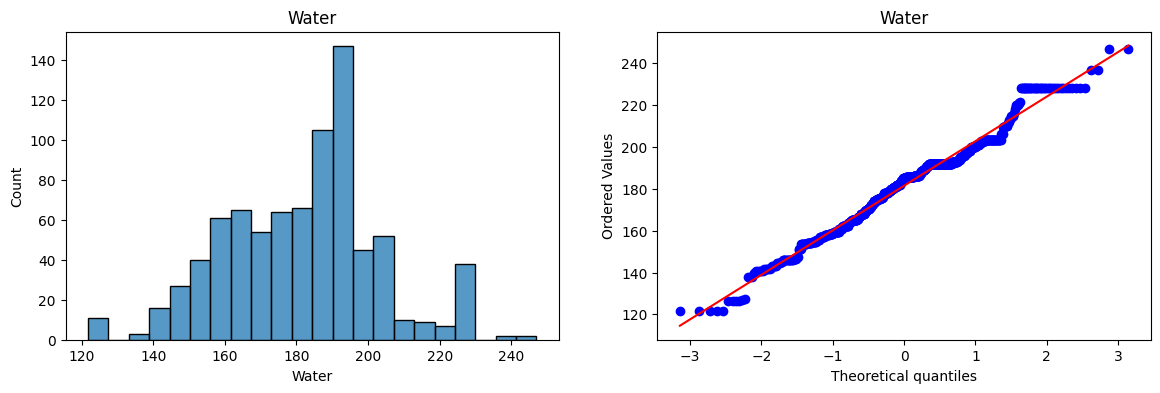

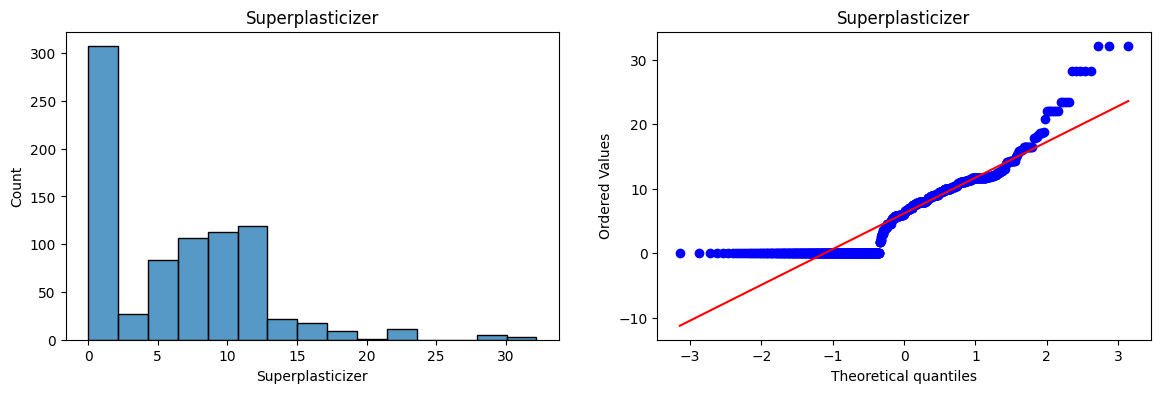

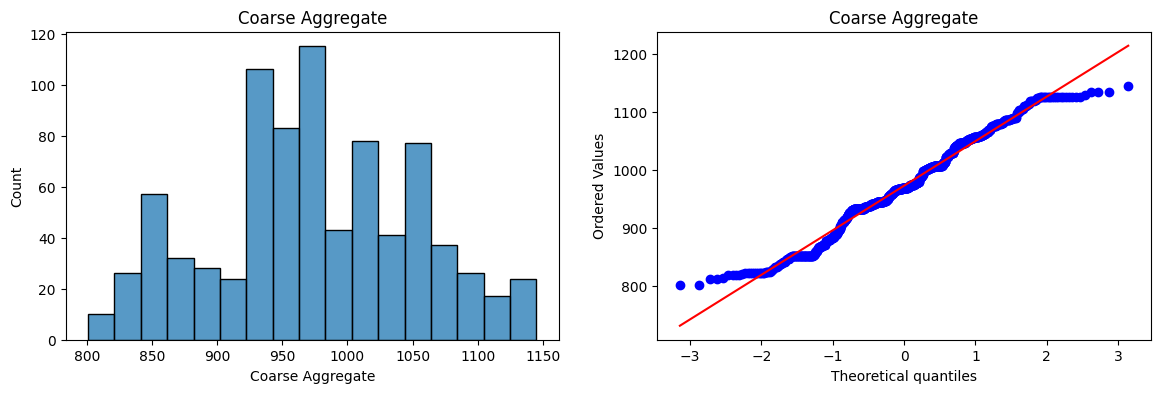

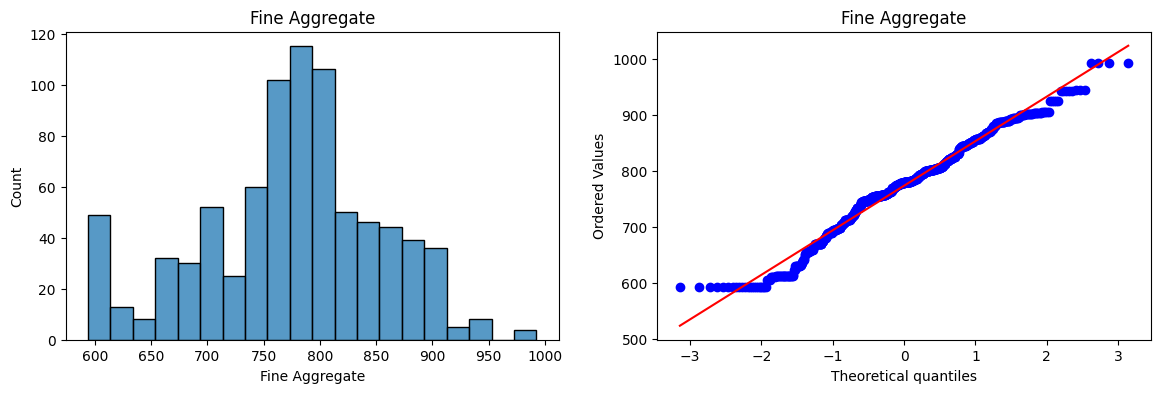

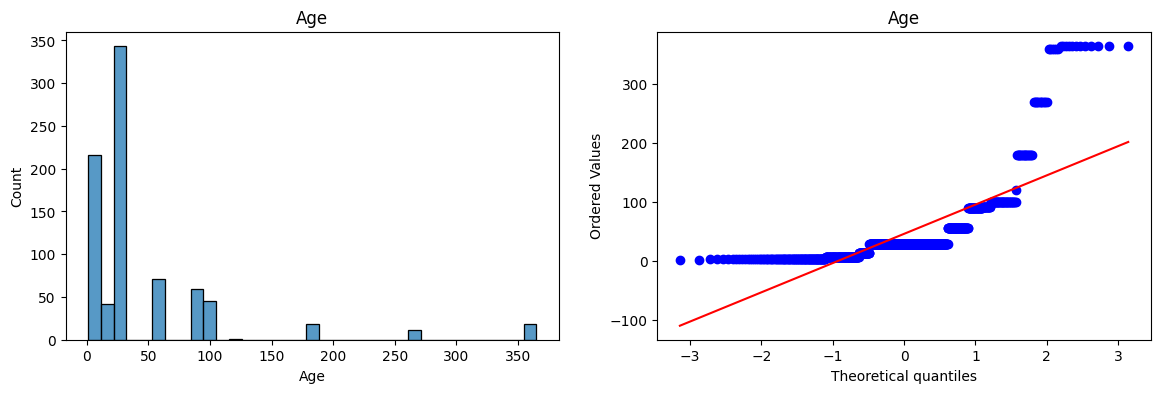

In [72]:
for col in X_train.columns:

  plt.figure(figsize=(14,4))

  plt.subplot(121)
  sns.histplot(X_train[col])
  plt.title(col)

  plt.subplot(122)
  stats.probplot(X_train[col], dist="norm", plot=plt)
  plt.title(col)

  plt.show()

In [100]:
# Power transformation (box-cox)

transformer_bc = PowerTransformer(method="box-cox")

# Adding 0.0001 to avoid zeroes

X_train_transformed = transformer_bc.fit_transform(X_train + 0.0001)
X_test_transformed = transformer_bc.fit_transform(X_test + 0.0001)

pd.DataFrame({"cols":X_train.columns, "box_cox_lambda":transformer_bc.lambdas_})

,cols,box_cox_lambda
0,Cement,0.015078
1,Blast Furnace Slag,0.056771
2,Fly Ash,-0.029961
3,Water,0.144542
4,Superplasticizer,0.124523
5,Coarse Aggregate,1.487261
6,Fine Aggregate,1.868962
7,Age,0.070789


In [101]:
# Box - Cox transformed modelling
lr = LinearRegression()

lr.fit(X_train_transformed, y_train)

r2 = r2_score(y_test, lr.predict(X_test_transformed))

r2

0.8095429699330903

In [102]:
non_transformed_cv = np.mean(cross_val_score(LinearRegression(), X_train,y_train, cv=10 ,scoring="r2"))
box_cox_transformed_cv = np.mean(cross_val_score(LinearRegression(), X_train_transformed,y_train, cv=10 ,scoring="r2"))

print(non_transformed_cv)
print(box_cox_transformed_cv)

0.5972235628410603
0.7927380726793581


In [103]:
X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)

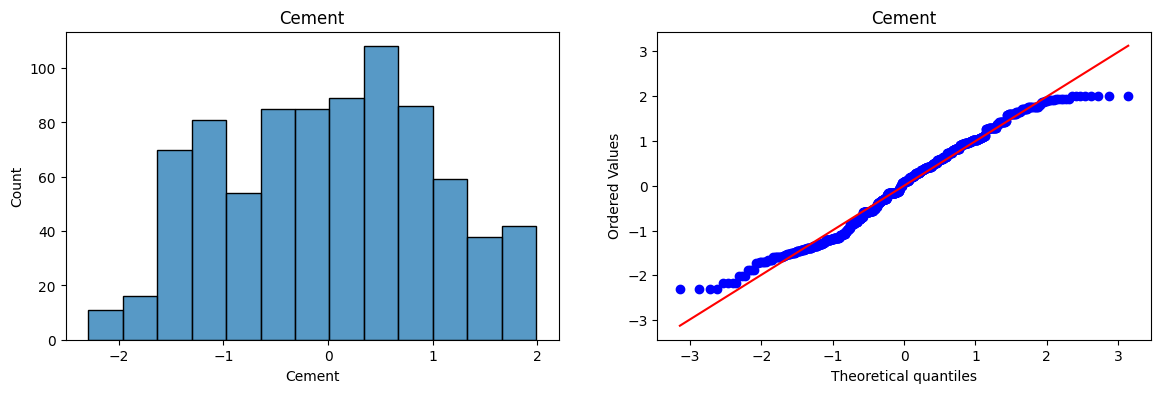

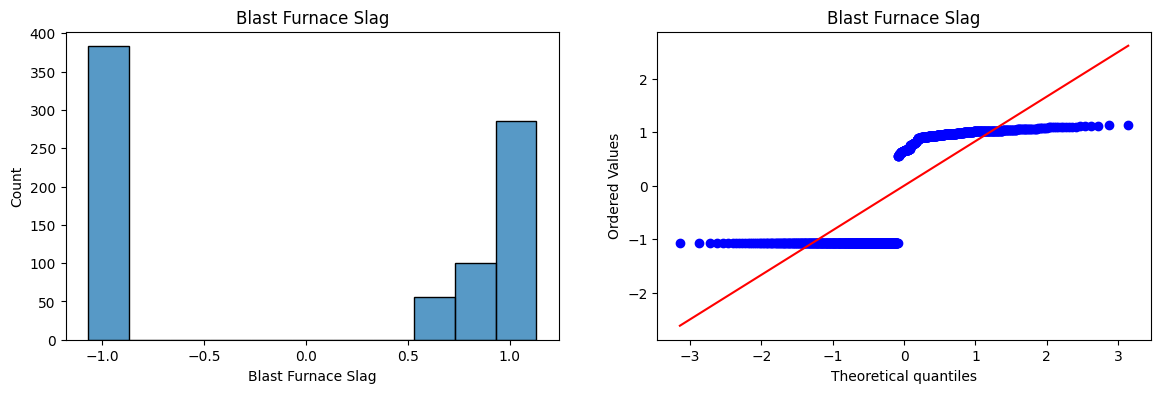

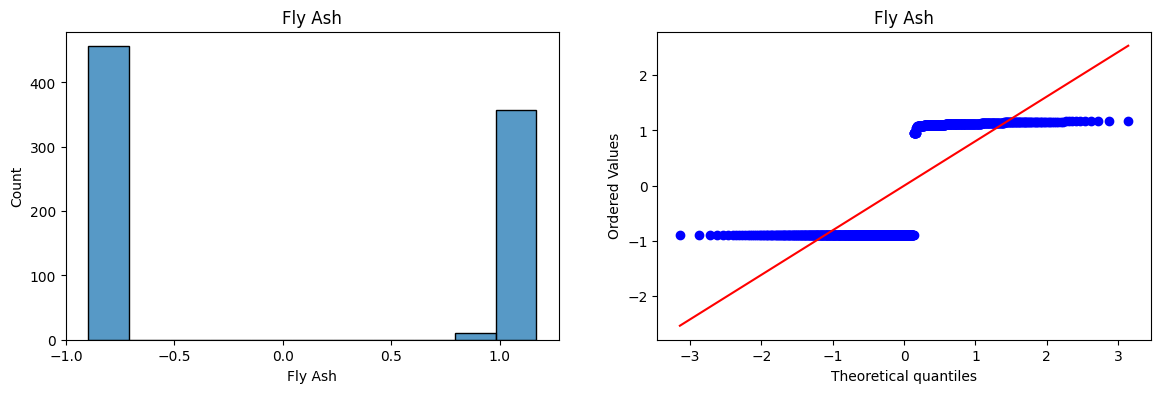

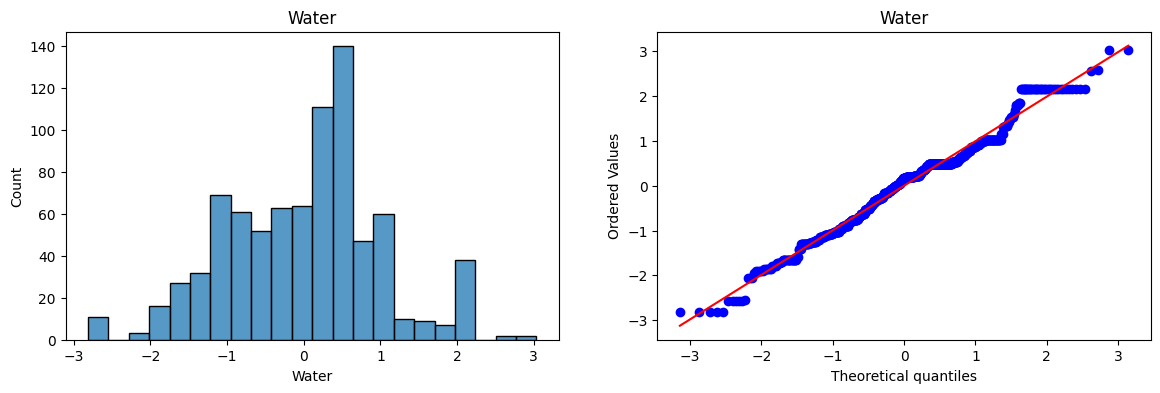

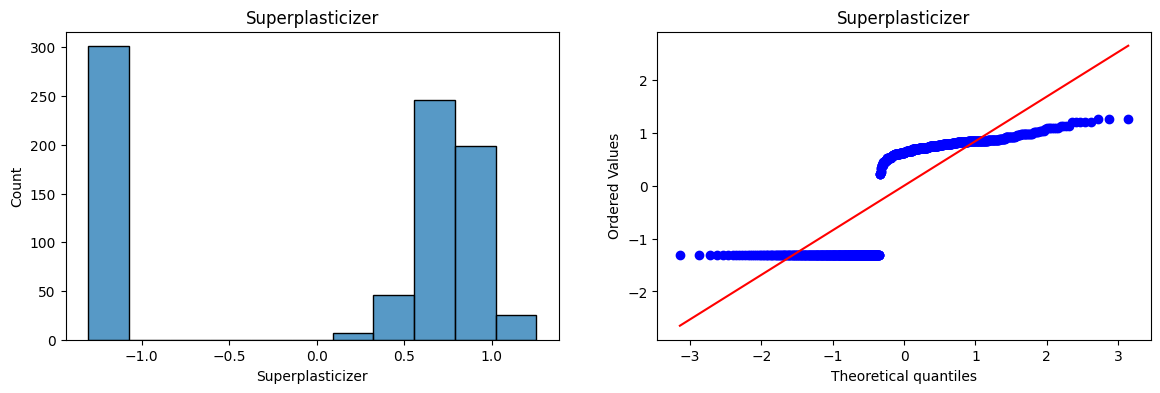

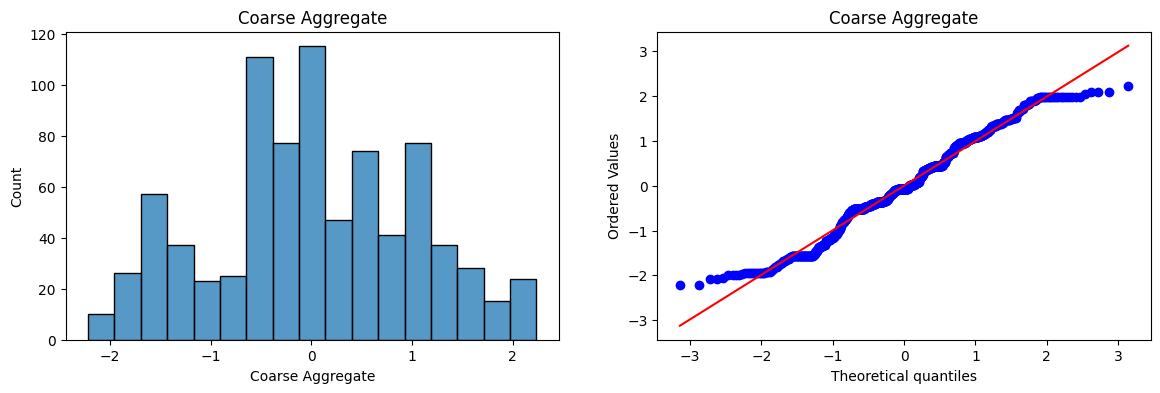

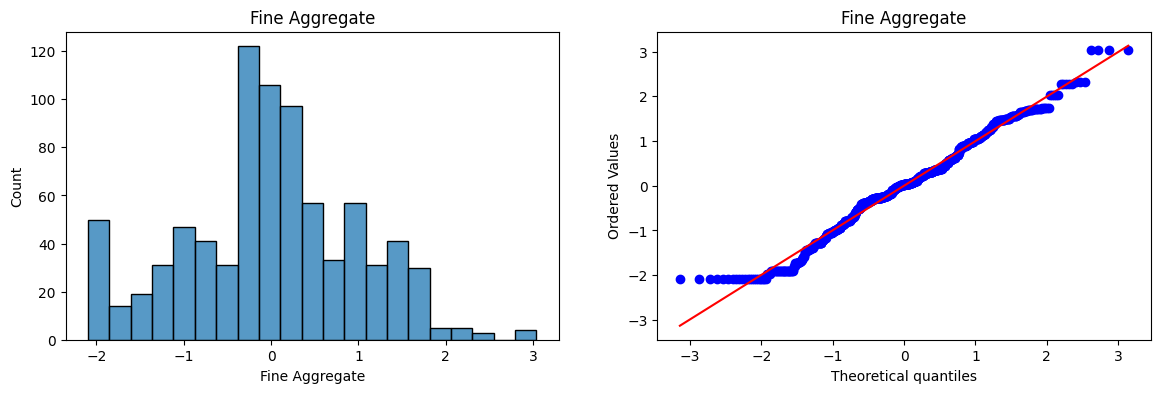

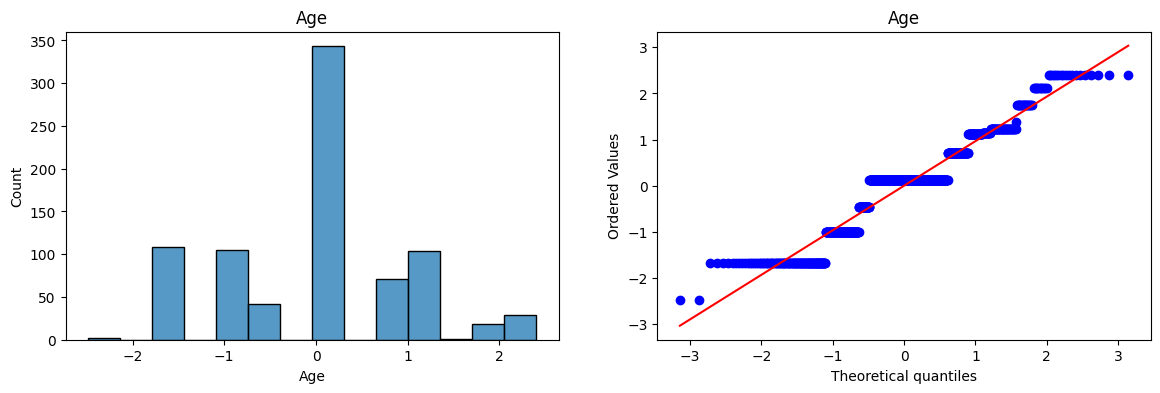

In [104]:
for col in X_train_transformed.columns:

  plt.figure(figsize=(14,4))

  plt.subplot(121)
  sns.histplot(X_train_transformed[col])
  plt.title(col)

  plt.subplot(122)
  stats.probplot(X_train_transformed[col], dist="norm", plot=plt)
  plt.title(col)

  plt.show()

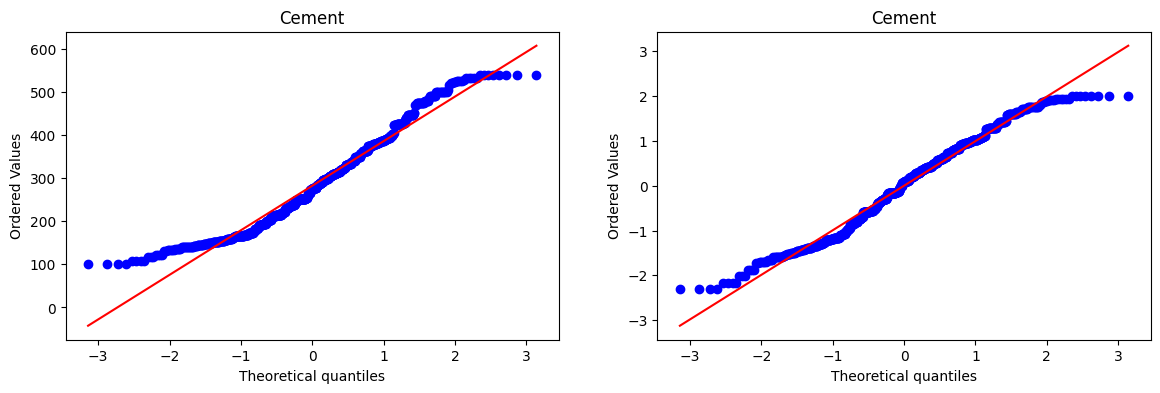

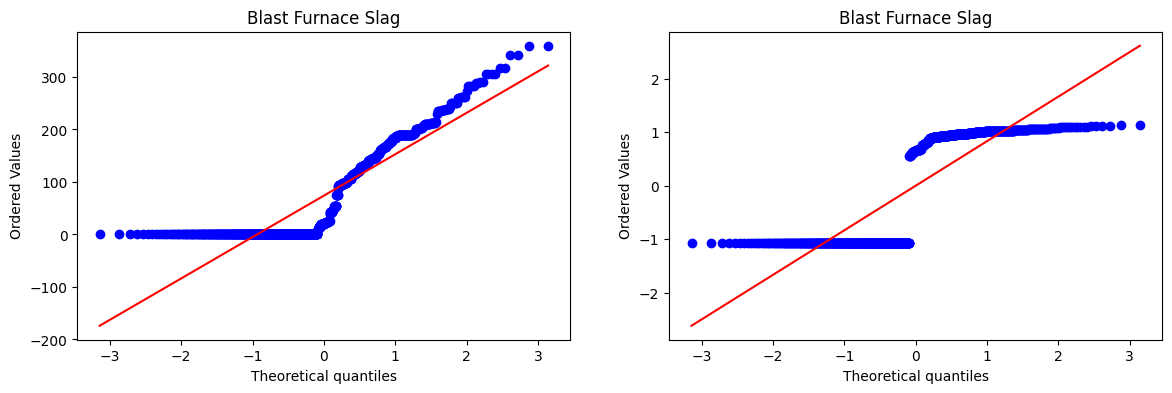

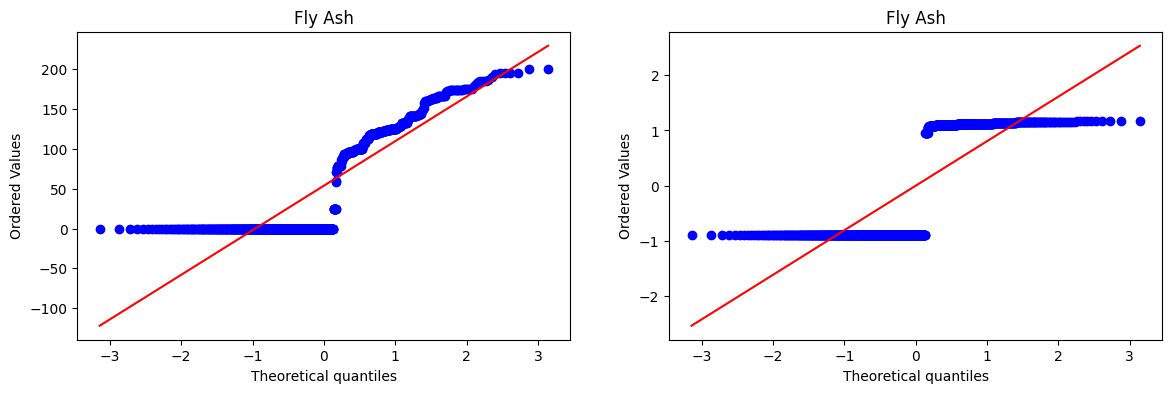

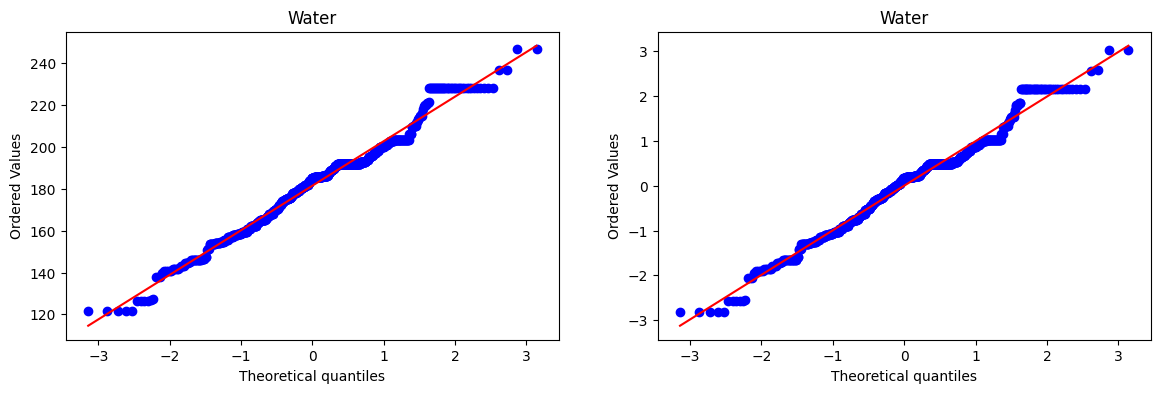

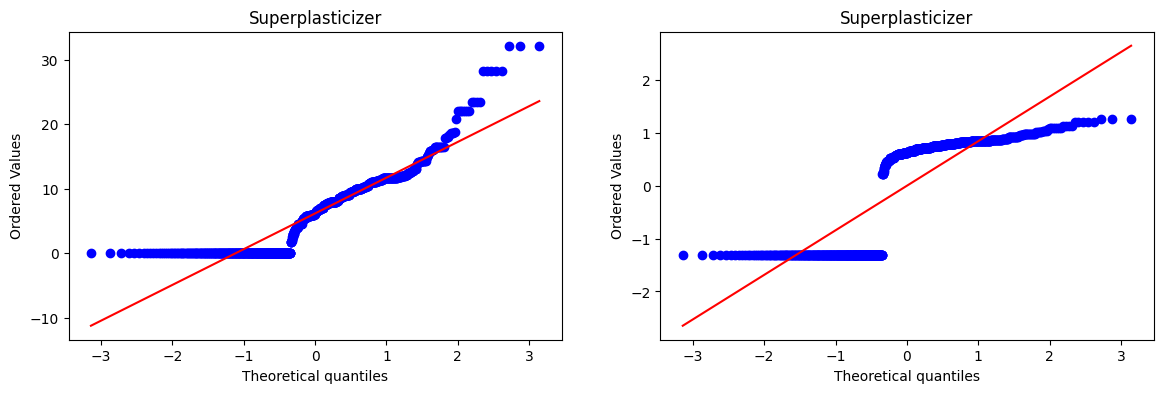

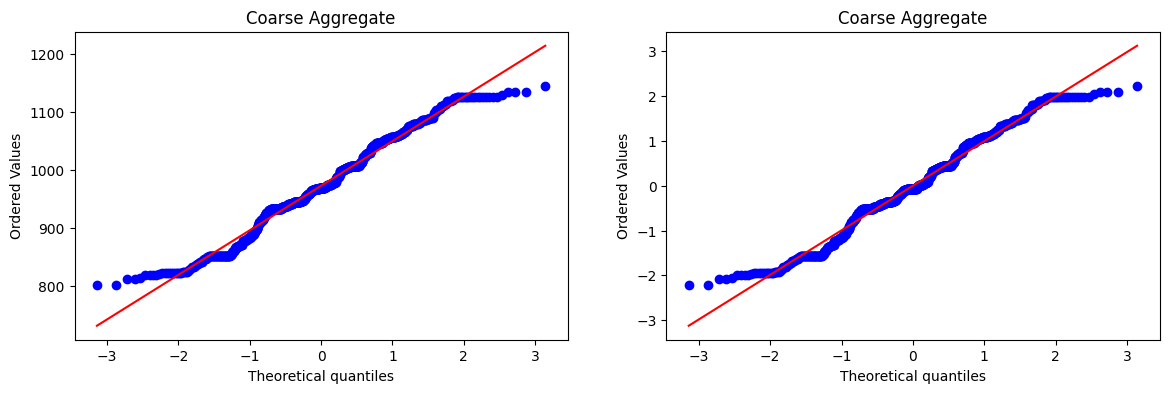

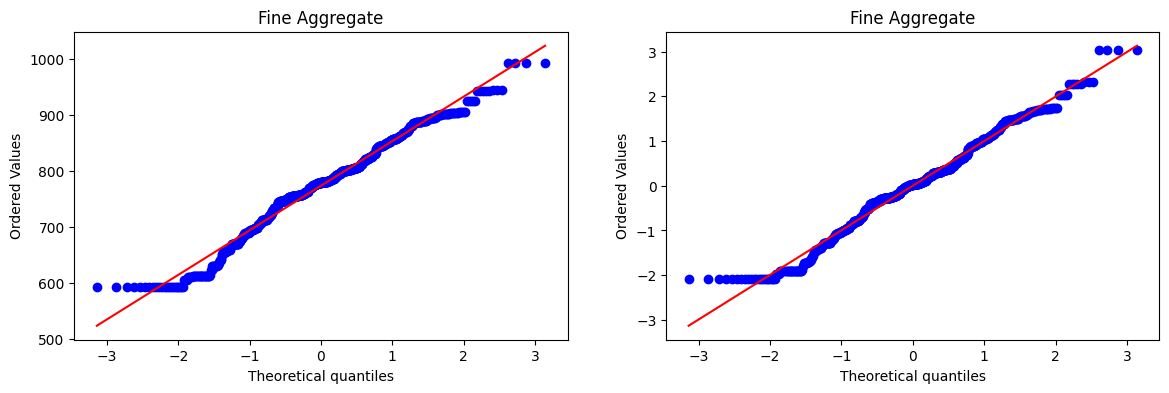

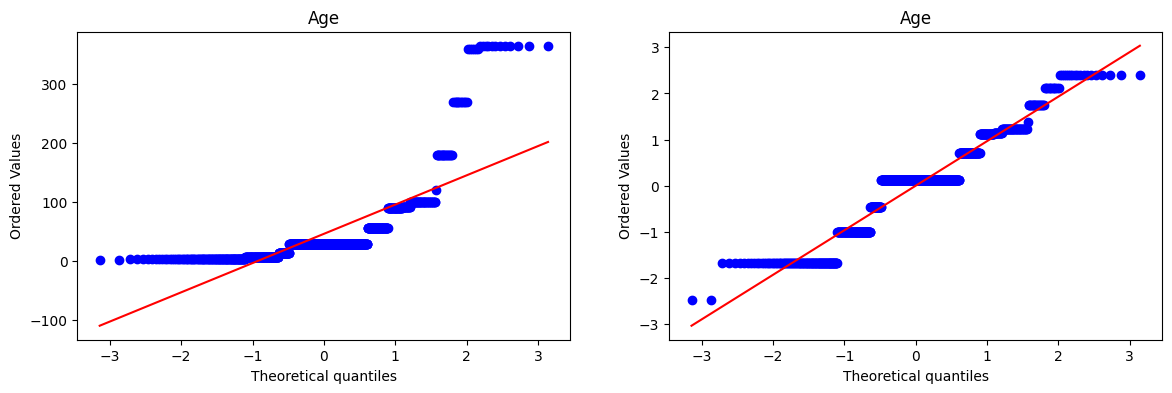

In [105]:
for col in X_train_transformed.columns:

  plt.figure(figsize=(14,4))

  plt.subplot(121)
  stats.probplot(X_train[col], dist="norm", plot=plt)
  plt.title(col)

  plt.subplot(122)
  stats.probplot(X_train_transformed[col], dist="norm", plot=plt)
  plt.title(col)

  plt.show()

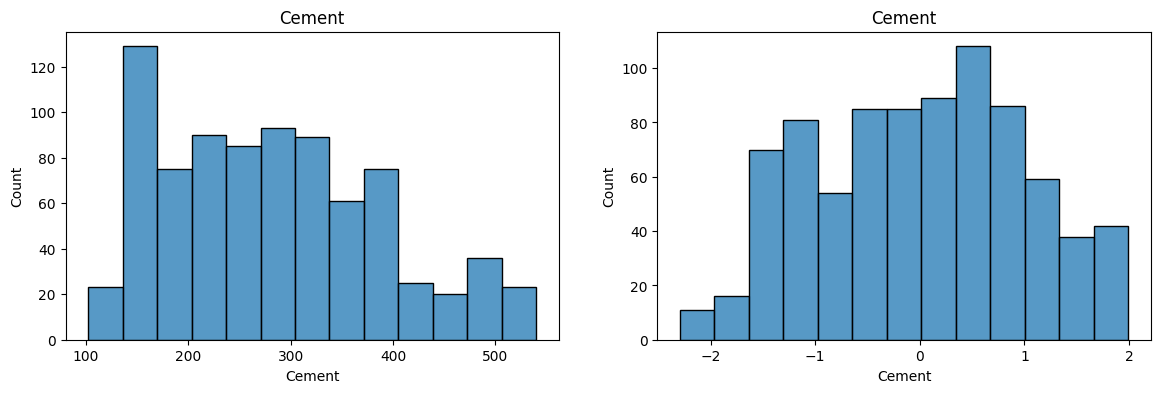

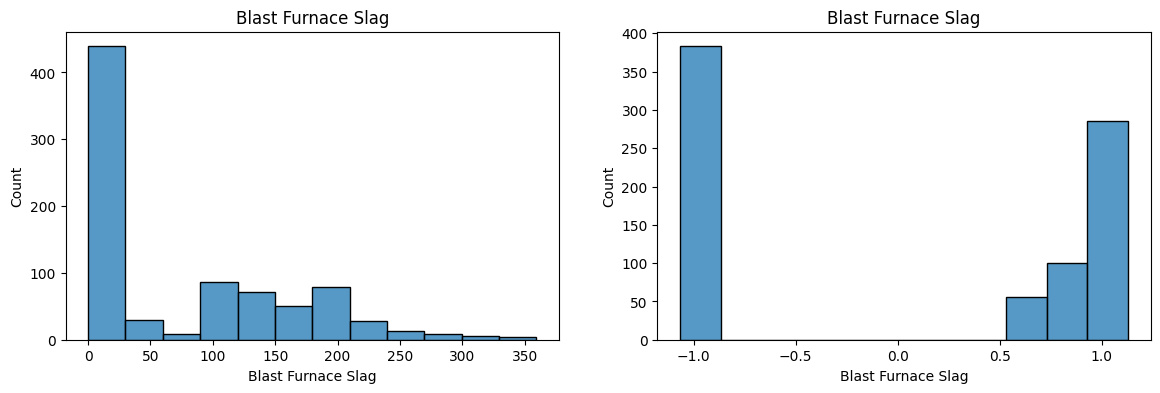

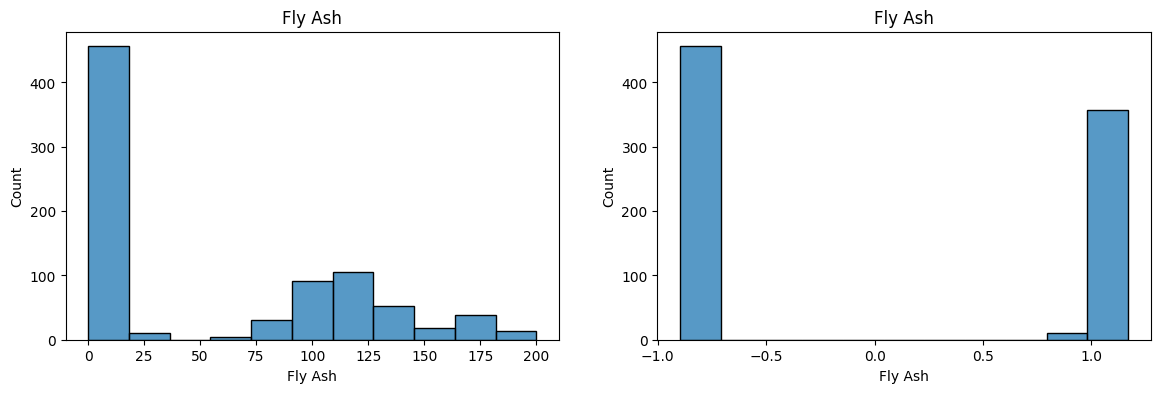

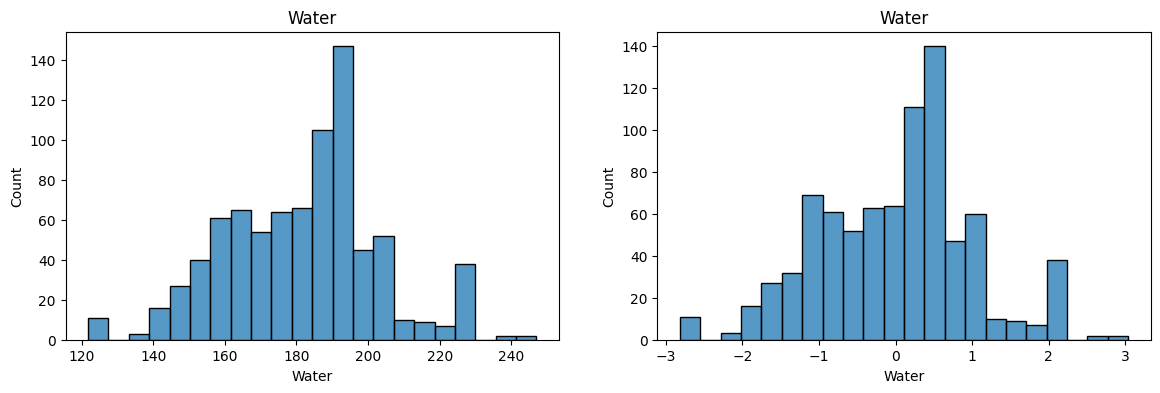

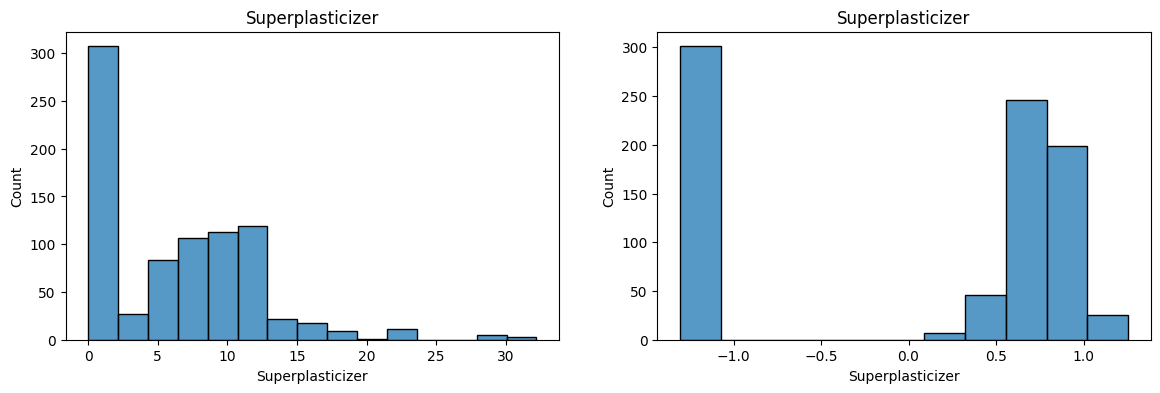

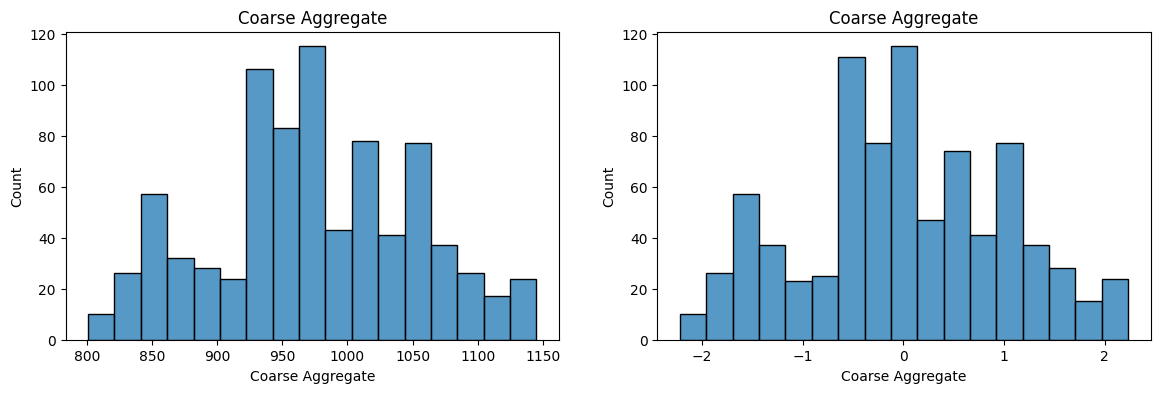

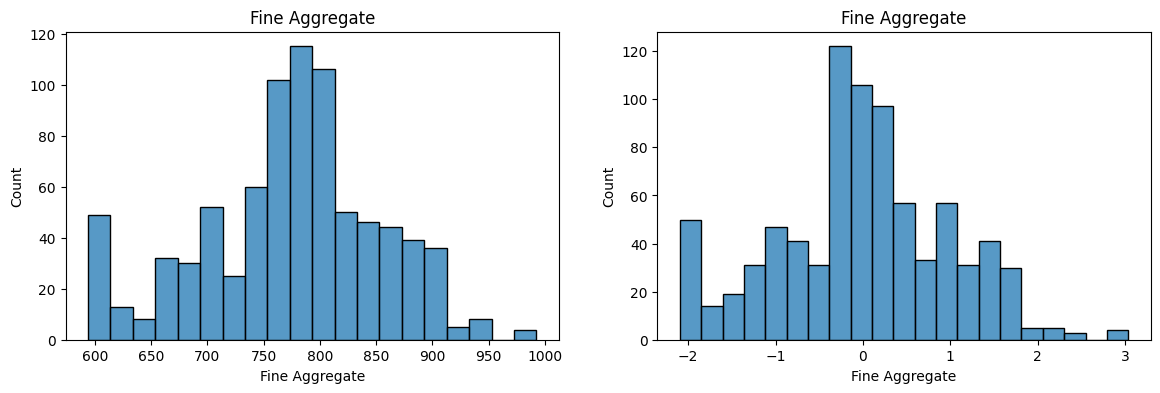

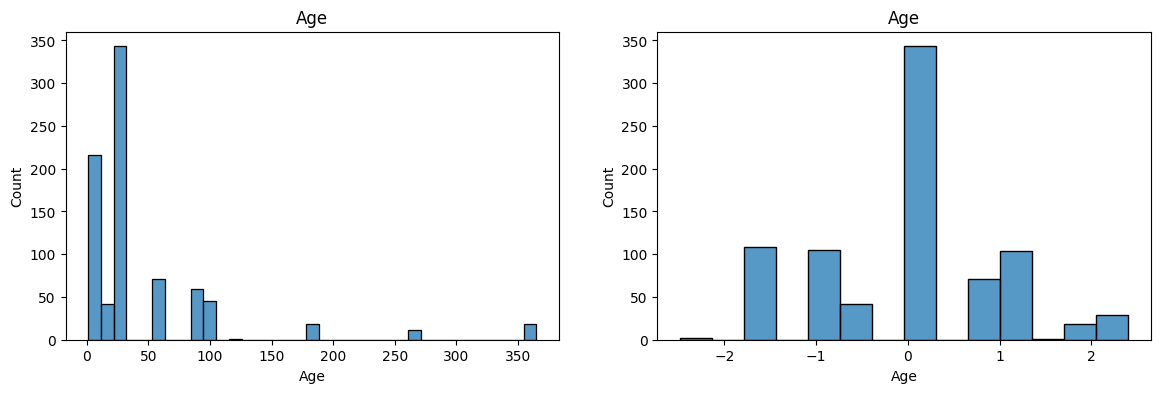

In [106]:
for col in X_train_transformed.columns:

  plt.figure(figsize=(14,4))

  plt.subplot(121)
  sns.histplot(X_train[col])
  plt.title(col)

  plt.subplot(122)
  sns.histplot(X_train_transformed[col])
  plt.title(col)

  plt.show()

In [107]:
# Power transformation (yoe-johnson)

transformer_yj = PowerTransformer(method="yeo-johnson")

X_train_transformed = transformer_yj.fit_transform(X_train)
X_test_transformed = transformer_yj.fit_transform(X_test)

pd.DataFrame({"cols":X_train.columns, "yeo_johnson_lambda":transformer_yj.lambdas_})

,cols,yeo_johnson_lambda
0,Cement,0.011890
1,Blast Furnace Slag,0.079352
2,Fly Ash,-0.100254
3,Water,0.139857
4,Superplasticizer,0.256899
5,Coarse Aggregate,1.487859
6,Fine Aggregate,1.870139
7,Age,0.025363


In [108]:
# Yoe - Johnson transformed modelling
lr = LinearRegression()

lr.fit(X_train_transformed, y_train)

r2 = r2_score(y_test, lr.predict(X_test_transformed))

r2

0.8148247993026329

In [109]:
yoe_johnson_transformed_cv = np.mean(cross_val_score(LinearRegression(), X_train_transformed,y_train, cv=10 ,scoring="r2"))

print(non_transformed_cv)
print(box_cox_transformed_cv)
print(yoe_johnson_transformed_cv)

0.5972235628410603
0.7927380726793581
0.7952944258794195


In [110]:
X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)

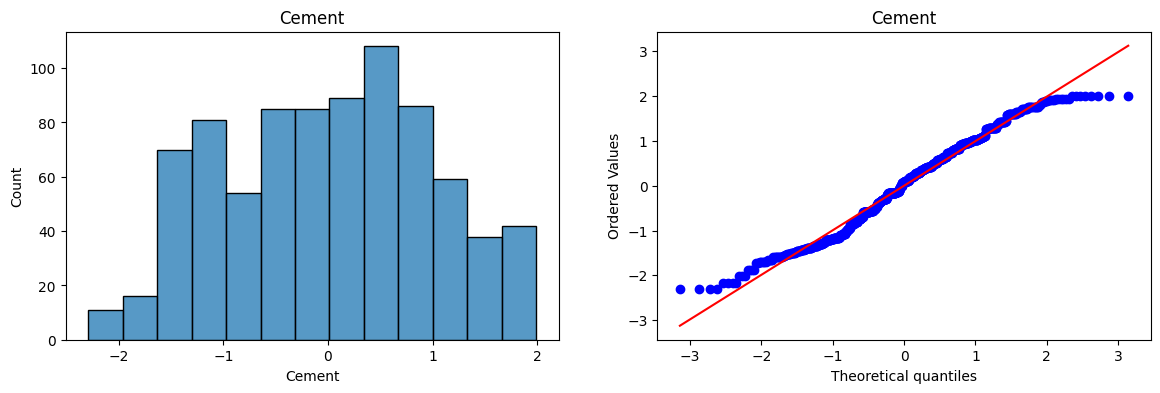

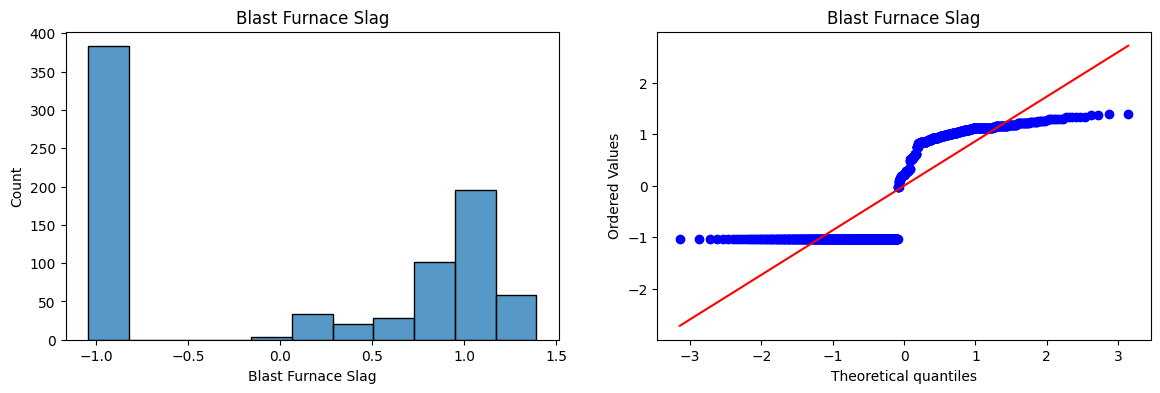

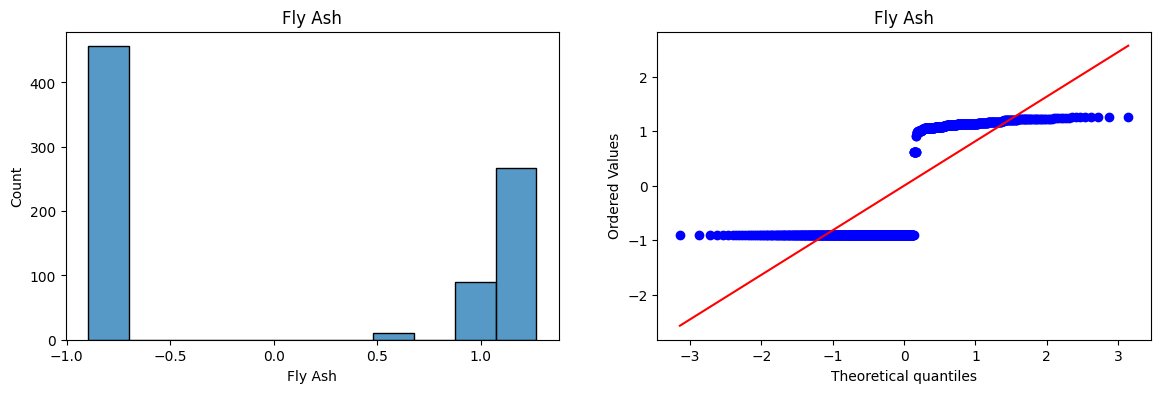

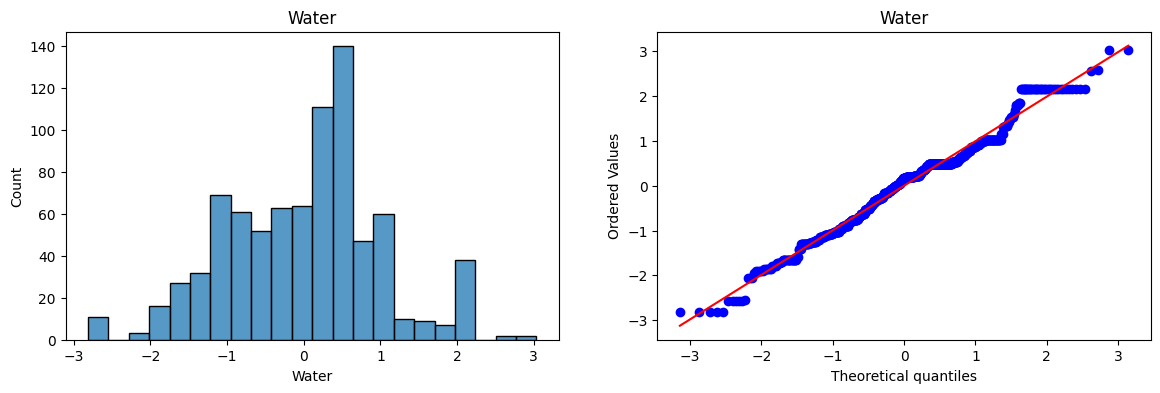

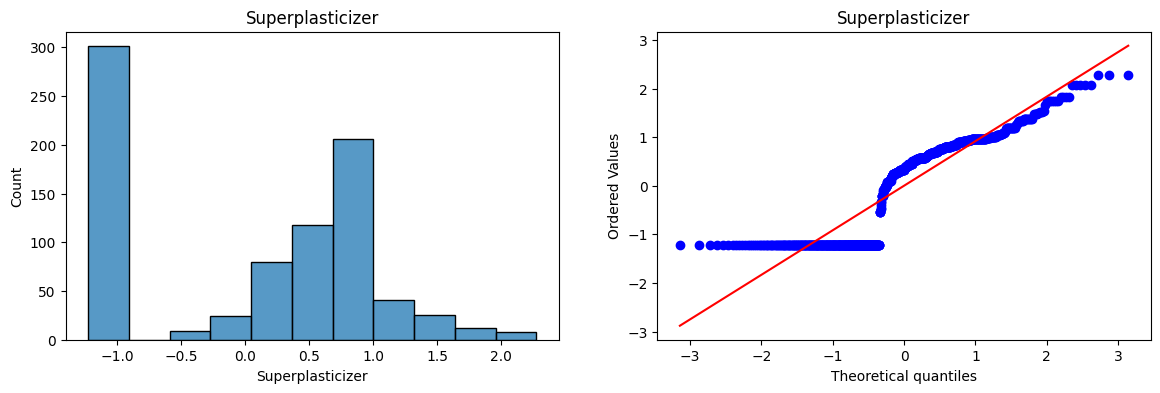

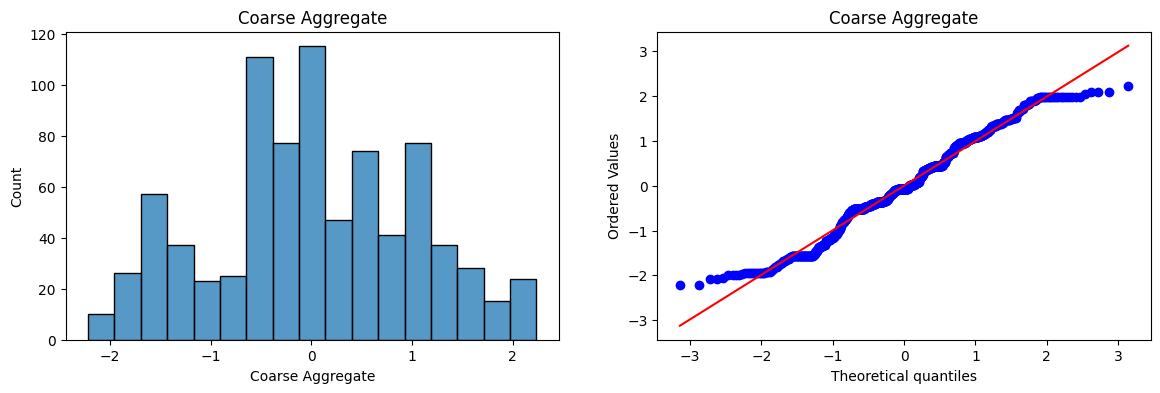

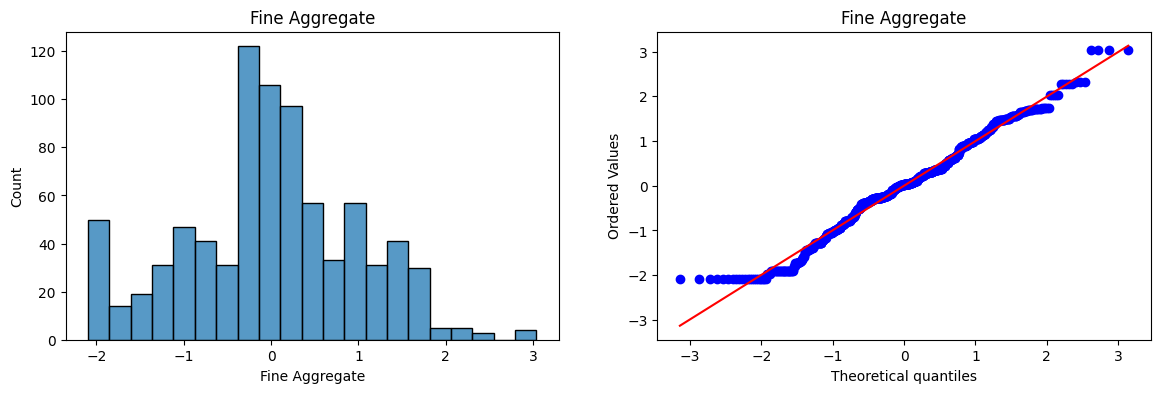

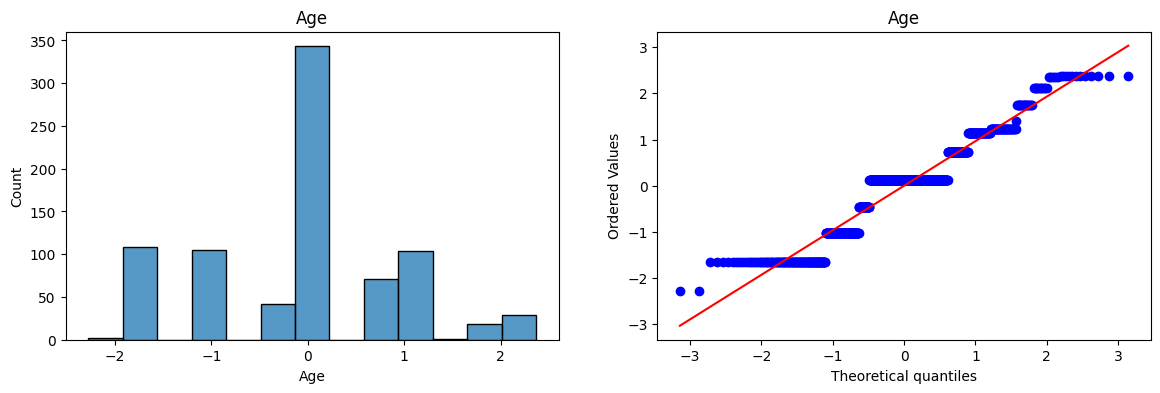

In [111]:
for col in X_train_transformed.columns:

  plt.figure(figsize=(14,4))

  plt.subplot(121)
  sns.histplot(X_train_transformed[col])
  plt.title(col)

  plt.subplot(122)
  stats.probplot(X_train_transformed[col], dist="norm", plot=plt)
  plt.title(col)

  plt.show()

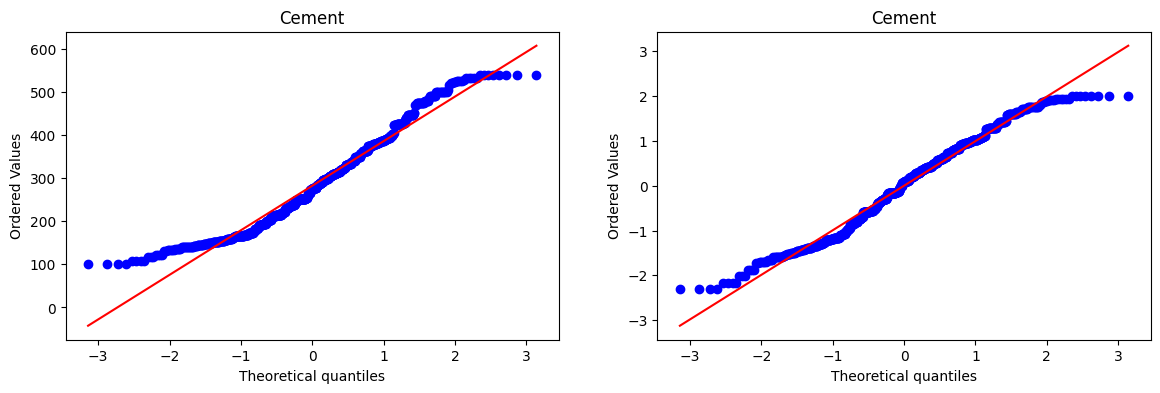

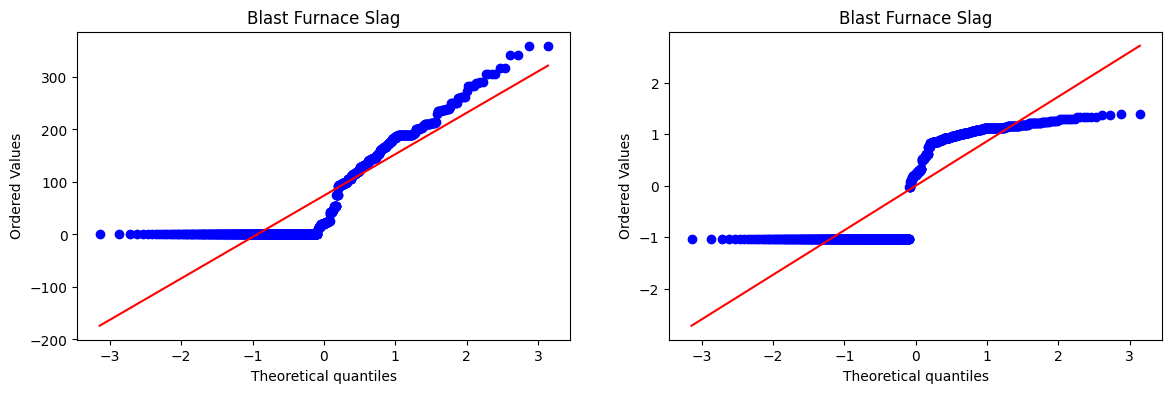

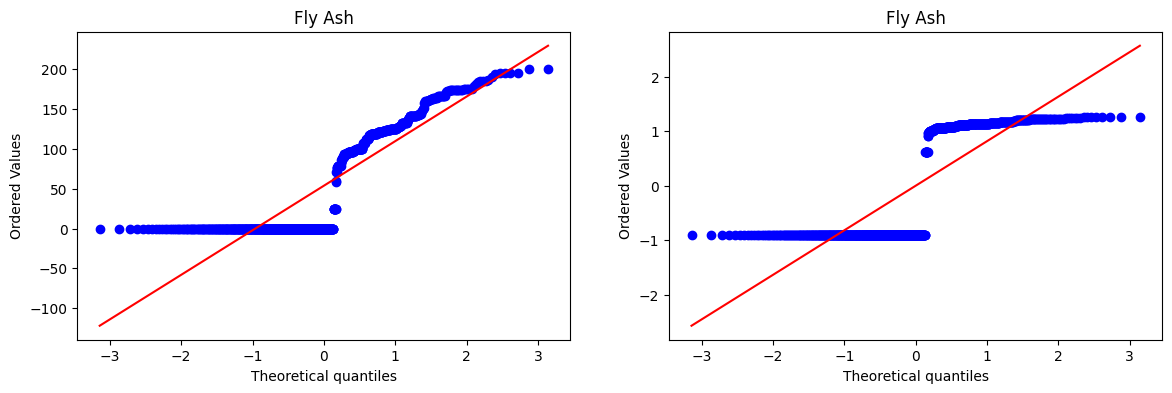

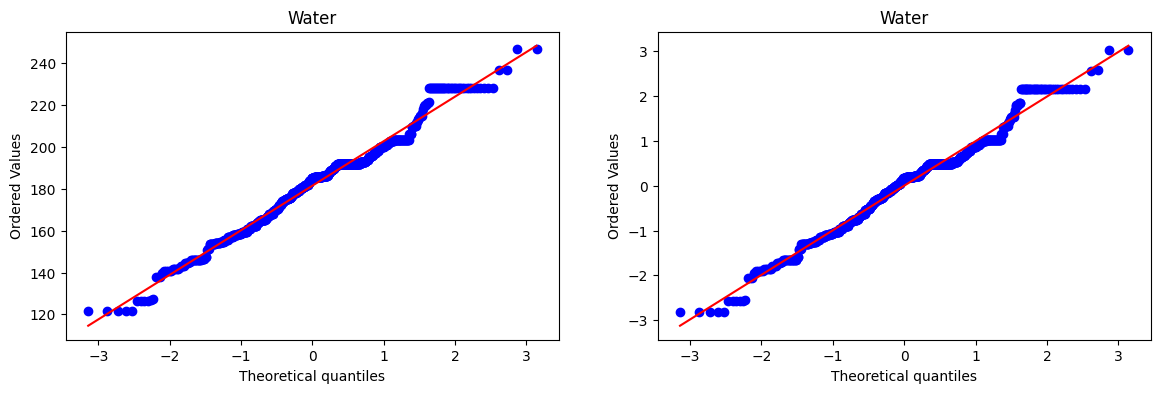

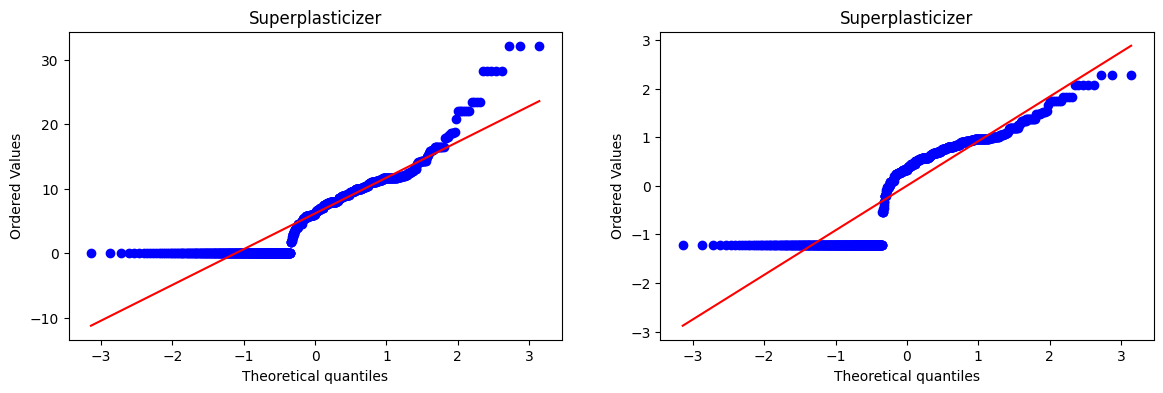

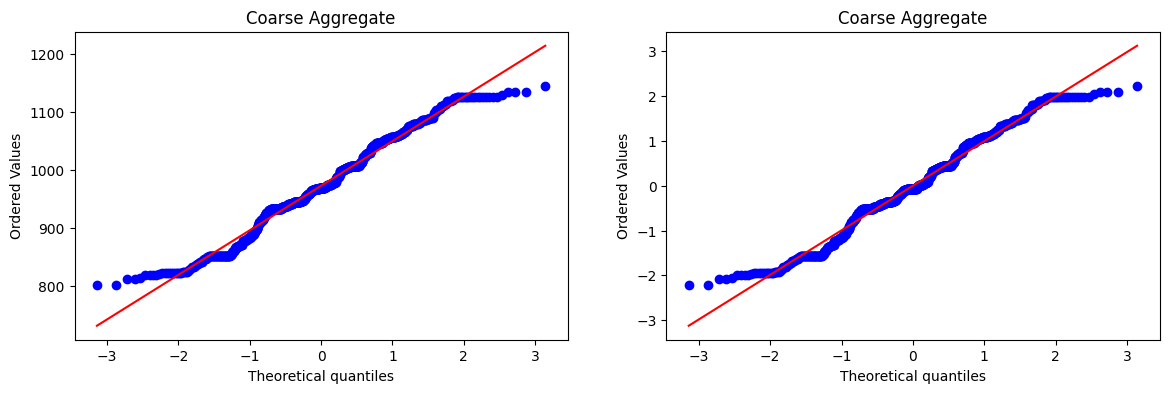

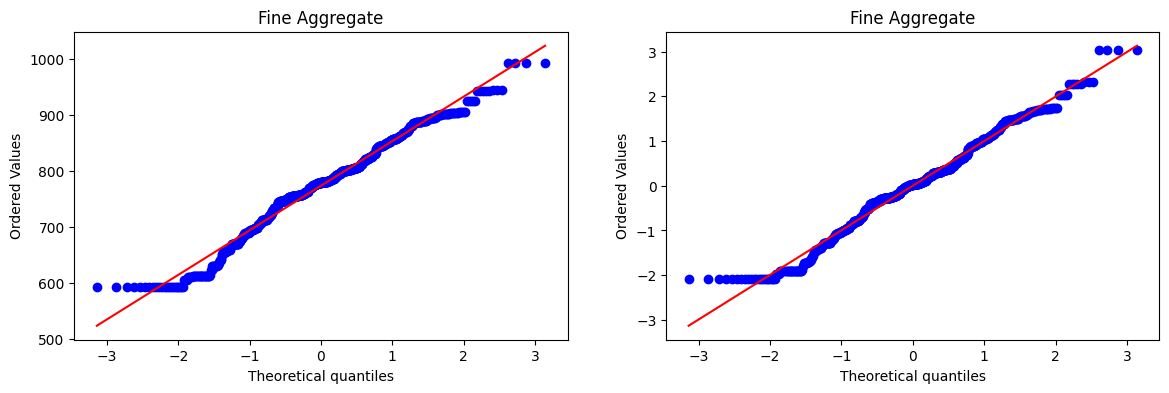

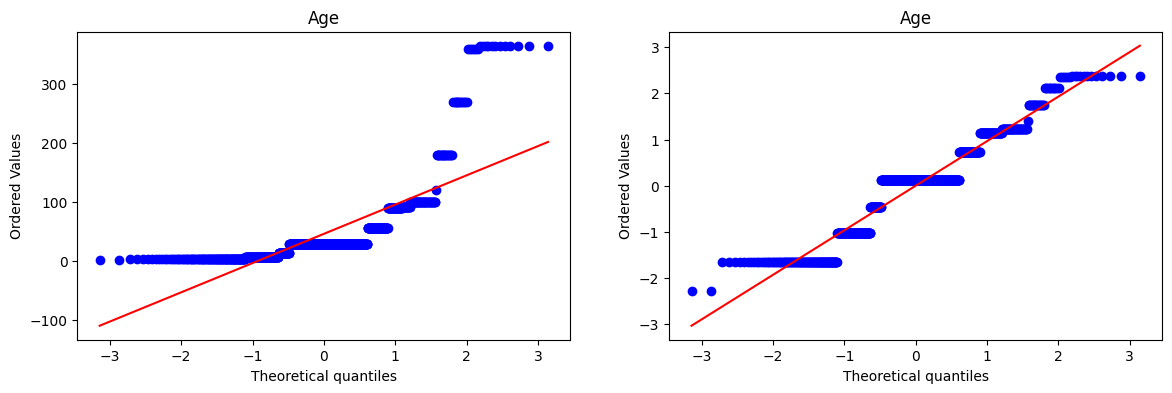

In [112]:
for col in X_train_transformed.columns:

  plt.figure(figsize=(14,4))

  plt.subplot(121)
  stats.probplot(X_train[col], dist="norm", plot=plt)
  plt.title(col)

  plt.subplot(122)
  stats.probplot(X_train_transformed[col], dist="norm", plot=plt)
  plt.title(col)

  plt.show()

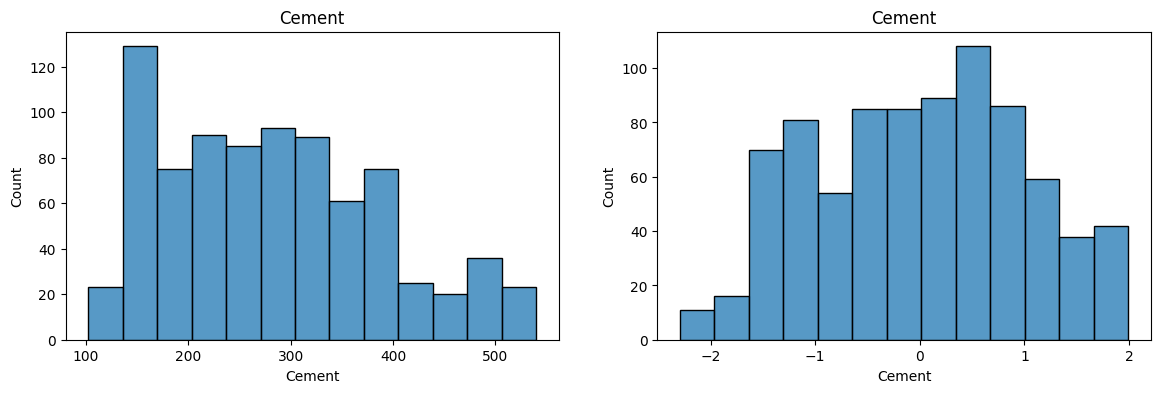

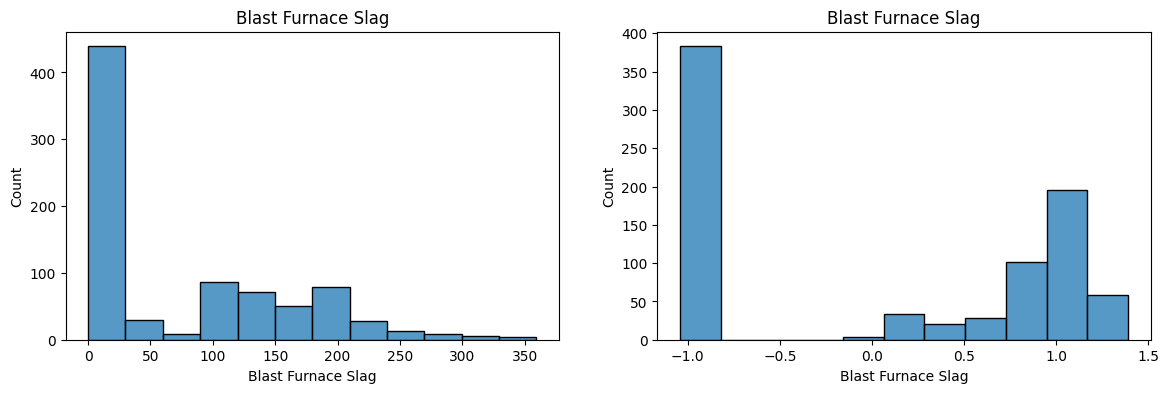

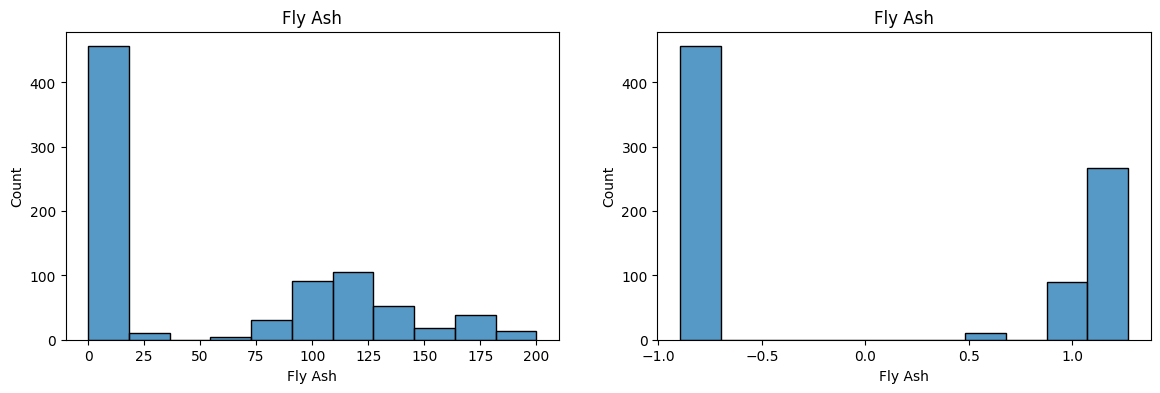

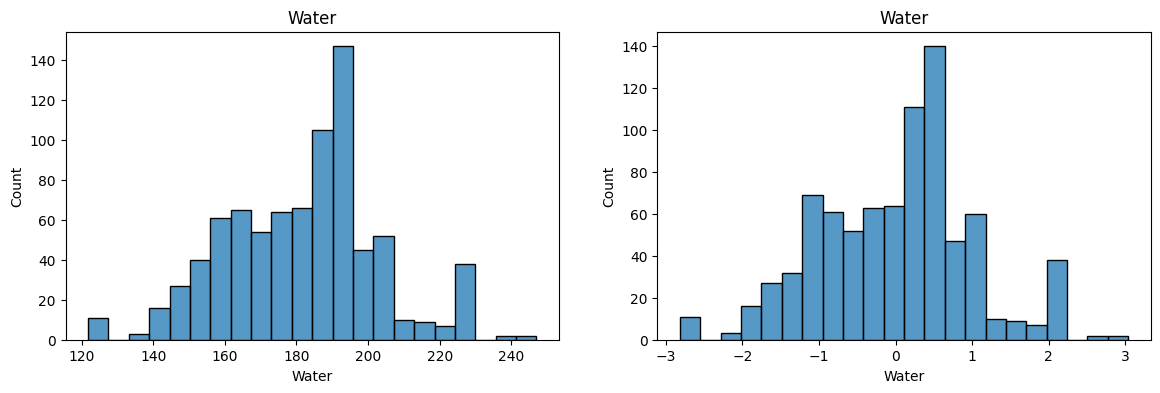

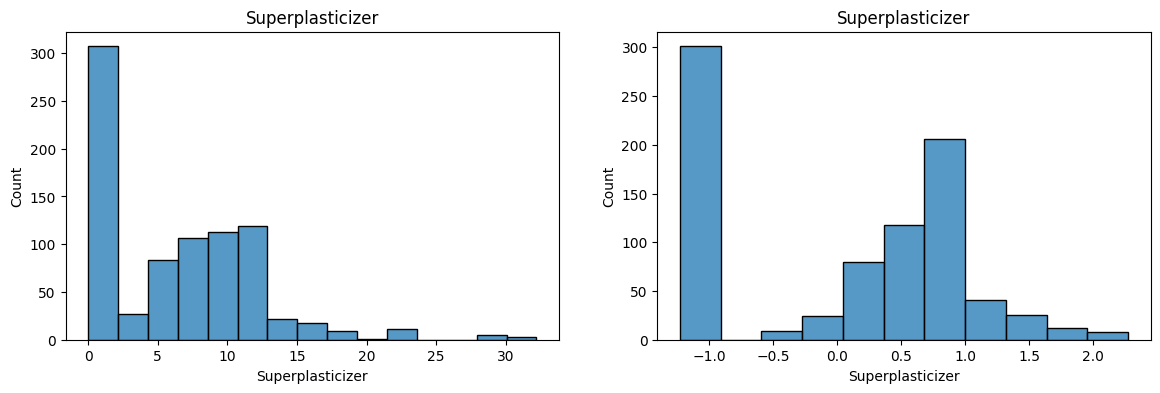

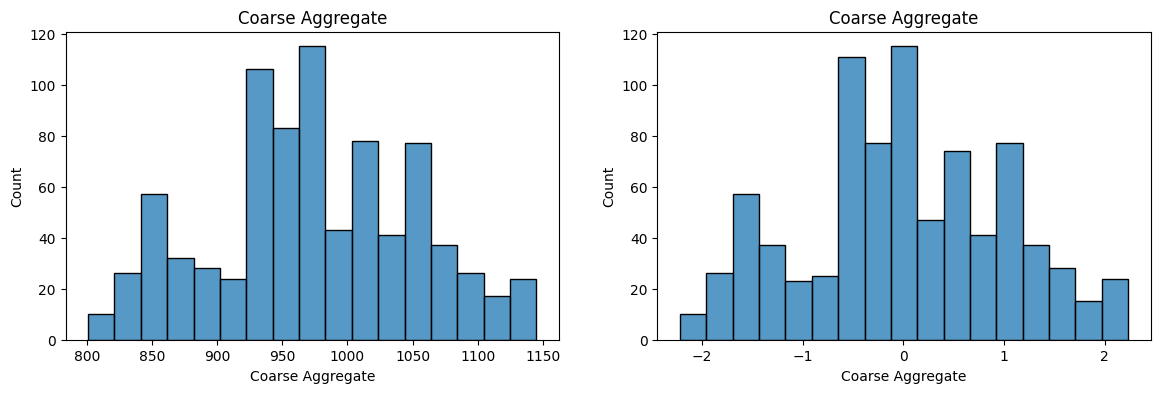

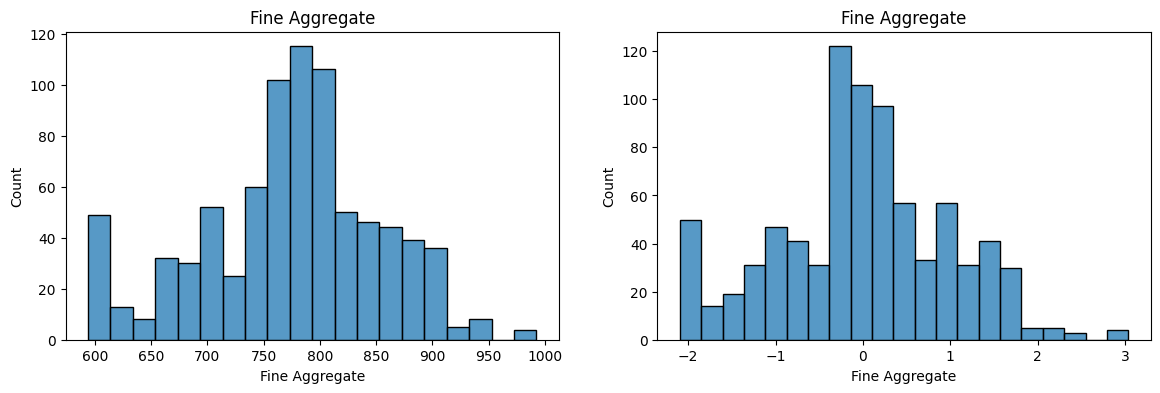

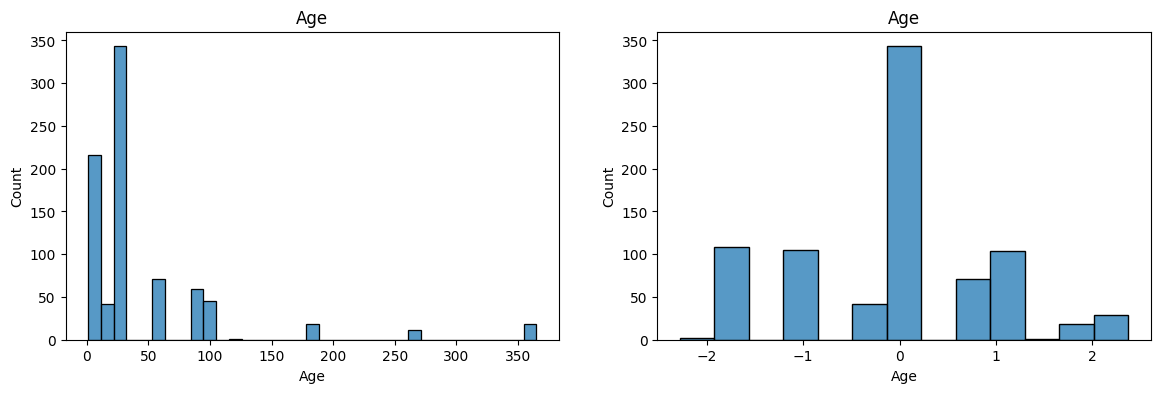

In [113]:
for col in X_train_transformed.columns:

  plt.figure(figsize=(14,4))

  plt.subplot(121)
  sns.histplot(X_train[col])
  plt.title(col)

  plt.subplot(122)
  sns.histplot(X_train_transformed[col])
  plt.title(col)

  plt.show()

In [115]:
# Lambda comparision

pd.DataFrame(
    {
        "Cols" : X_train.columns,
        "Box-Cox Lambdas" : transformer_bc.lambdas_,
        "Yoe-Johnson Lambdas" : transformer_yj.lambdas_
    }
)

,Cols,Box-Cox Lambdas,Yoe-Johnson Lambdas
0,Cement,0.015078,0.011890
1,Blast Furnace Slag,0.056771,0.079352
2,Fly Ash,-0.029961,-0.100254
3,Water,0.144542,0.139857
4,Superplasticizer,0.124523,0.256899
5,Coarse Aggregate,1.487261,1.487859
6,Fine Aggregate,1.868962,1.870139
7,Age,0.070789,0.025363
